# Clean

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.special import erfinv

# Read the combined CSV file
df = pd.read_csv('X3/combined_resampled_data.csv')

# Calculate the magnitude of the horizontal component
df['H'] = np.sqrt(df['Accel_X (m/s^2)']**2 + df['Accel_Y (m/s^2)']**2)

# Calculate the inclination angle in degrees
df['Inclination (degrees)'] = np.degrees(np.arctan(df['H'] / df['Accel_Z (m/s^2)']))


# Function to detect outliers using Chauvenet's criterion and replace them with the median
def replace_outliers_with_median(series):
    mean = series.mean()
    std = series.std()
    N = len(series)
    criterion = 1.0 / (2 * N)
    deviation = np.abs(series - mean) / std
    threshold = std * np.sqrt(2) * erfinv(1 - criterion)
    mask = deviation < threshold
    series_outliers_replaced = series.copy()
    series_outliers_replaced[~mask] = series.median()  # Replace outliers with median
    return series_outliers_replaced

# Apply Chauvenet's criterion and replace outliers for each numerical column
columns_to_check = [col for col in df.columns if col not in ['timestamp', 'app', 'Time (s)']]
df[columns_to_check] = df[columns_to_check].apply(replace_outliers_with_median)

# Function to apply lowpass filter
def lowpass_filter(data, cutoff=0.1, fs=1.0, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

# Apply lowpass filter to each numerical column except 'timestamp' and 'Time (s)'
for col in columns_to_check:
    df[col] = lowpass_filter(df[col].values)


# Save the cleaned and processed dataframe to a new CSV file
df.to_csv('X3/data_X3.csv', index=False)

print("Data cleaned and saved to 'cleaned_combined_data_no_outliers_noise.csv'")


# Exploratory Data Analysis

# Exploratory Data Analysis/Visualization 

## Load Packages

In [1]:
!pip install optuna 

import numpy as np
import pandas as pd
import os
from os import listdir
from os.path import isfile, join
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import zscore
from scipy import fftpack
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
import optuna


[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: pip install --upgrade pip
/shared-libs/python3.9/py/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Files

In [2]:
accel = pd.read_parquet("all_acceleration.parquet.gzip")
lin_accel = pd.read_parquet("all_lin_acceleration.parquet.gzip")
baro = pd.read_parquet("all_barometer.parquet.gzip")
gyro = pd.read_parquet("all_gyroscope.parquet.gzip")

## Box Plots (Figure 2)

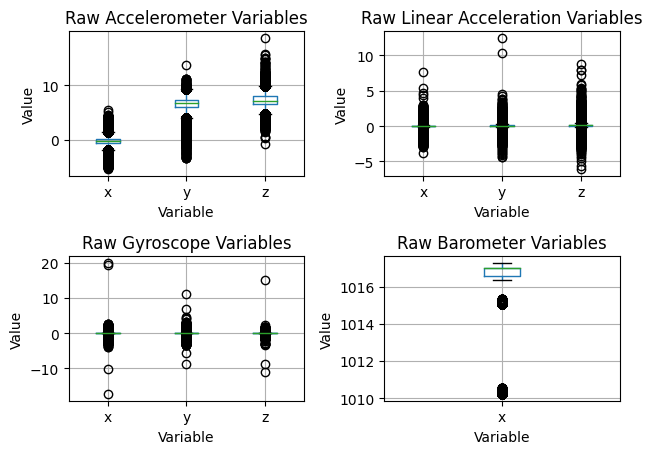

In [6]:
plt.subplot(2, 2, 1)
accel.iloc[:,1:].boxplot()
plt.title('Raw Accelerometer Variables')
plt.suptitle('')  # Suppress the automatic title to keep the plot clean
plt.xlabel('Variable')
plt.ylabel('Value')

plt.subplot(2, 2, 2)
lin_accel.iloc[:,1:].boxplot()
plt.title('Raw Linear Acceleration Variables')
plt.suptitle('')  # Suppress the automatic title to keep the plot clean
plt.xlabel('Variable')
plt.ylabel('Value')

plt.subplot(2, 2, 3)
gyro.iloc[:,1:].boxplot()
plt.title('Raw Gyroscope Variables')
plt.suptitle('')  # Suppress the automatic title to keep the plot clean
plt.xlabel('Variable')
plt.ylabel('Value')

plt.subplot(2, 2, 4)
baro.iloc[:,1:].boxplot()
plt.title('Raw Barometer Variables')
plt.suptitle('')  # Suppress the automatic title to keep the plot clean
plt.xlabel('Variable')
plt.ylabel('Value')

plt.tight_layout()

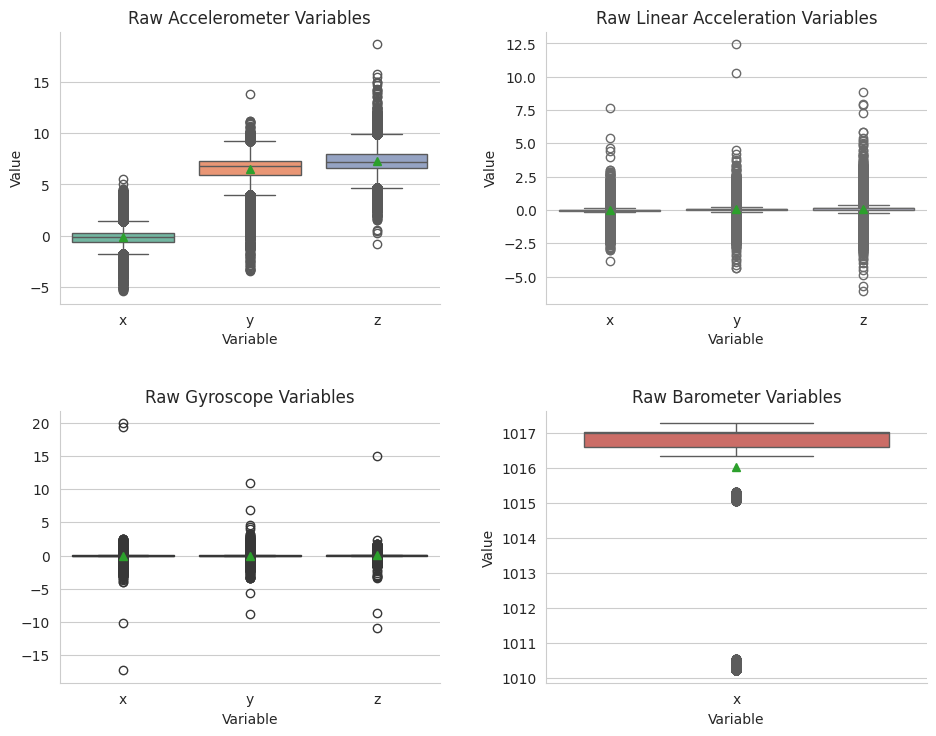

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for aesthetics

# Example data (replace with your actual data)
accel = accel.select_dtypes(include='number')
lin_accel = lin_accel.select_dtypes(include='number')
gyro = gyro.select_dtypes(include='number')
baro = baro.select_dtypes(include='number')

# Define subplots with seaborn color palette
sns.set_style("whitegrid")  # Set seaborn theme (optional)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot each subplot with customizations
sns.boxplot(
    data=accel,
    ax=axs[0, 0],
    showmeans=True,  # Show mean as a point
    palette="Set2"  # Use seaborn color palette
)
axs[0, 0].set_title('Raw Accelerometer Variables')
axs[0, 0].set_xlabel('Variable')
axs[0, 0].set_ylabel('Value')

sns.boxplot(
    data=lin_accel,
    ax=axs[0, 1],
    showmeans=True,
    palette="Set3"
)
axs[0, 1].set_title('Raw Linear Acceleration Variables')
axs[0, 1].set_xlabel('Variable')
axs[0, 1].set_ylabel('Value')

sns.boxplot(
    data=gyro,
    ax=axs[1, 0],
    showmeans=True,
    palette="Dark2"
)
axs[1, 0].set_title('Raw Gyroscope Variables')
axs[1, 0].set_xlabel('Variable')
axs[1, 1].set_ylabel('Value')

sns.boxplot(
    data=baro,
    ax=axs[1, 1],
    showmeans=True,
    palette="hls"
)
axs[1, 1].set_title('Raw Barometer Variables')
axs[1, 1].set_xlabel('Variable')
axs[1, 1].set_ylabel('Value')

# Adjust layout and remove spines
plt.tight_layout(pad=3.0)
for ax in axs.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Suppress the overall title
plt.suptitle('')

# Display the plot
plt.show()

## Raw Timeseries Plot for the Data (Figure 4)

In [9]:
accel = pd.read_parquet("all_acceleration.parquet.gzip")
lin_accel = pd.read_parquet("all_lin_acceleration.parquet.gzip")
baro = pd.read_parquet("all_barometer.parquet.gzip")
gyro = pd.read_parquet("all_gyroscope.parquet.gzip")

In [10]:
print(accel.columns)
print(baro.columns)
print(gyro.columns)
print(lin_accel.columns)

Index(['time', 'x', 'y', 'z', 'source_name'], dtype='object')
Index(['time', 'x', 'source_name'], dtype='object')
Index(['time', 'x', 'y', 'z', 'source_name'], dtype='object')
Index(['time', 'x', 'y', 'z', 'source_name'], dtype='object')


In [11]:
accel.set_index('time', inplace=True)
baro.set_index('time', inplace=True)
gyro.set_index('time', inplace=True)
lin_accel.set_index('time', inplace=True)

In [12]:
datasets = [accel, baro, gyro, lin_accel]
dataset_names = ['Accelerometer', 'Barometer', 'Gyroscope', 'Linear Acceleration']

/tmp/ipykernel_686/340381032.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


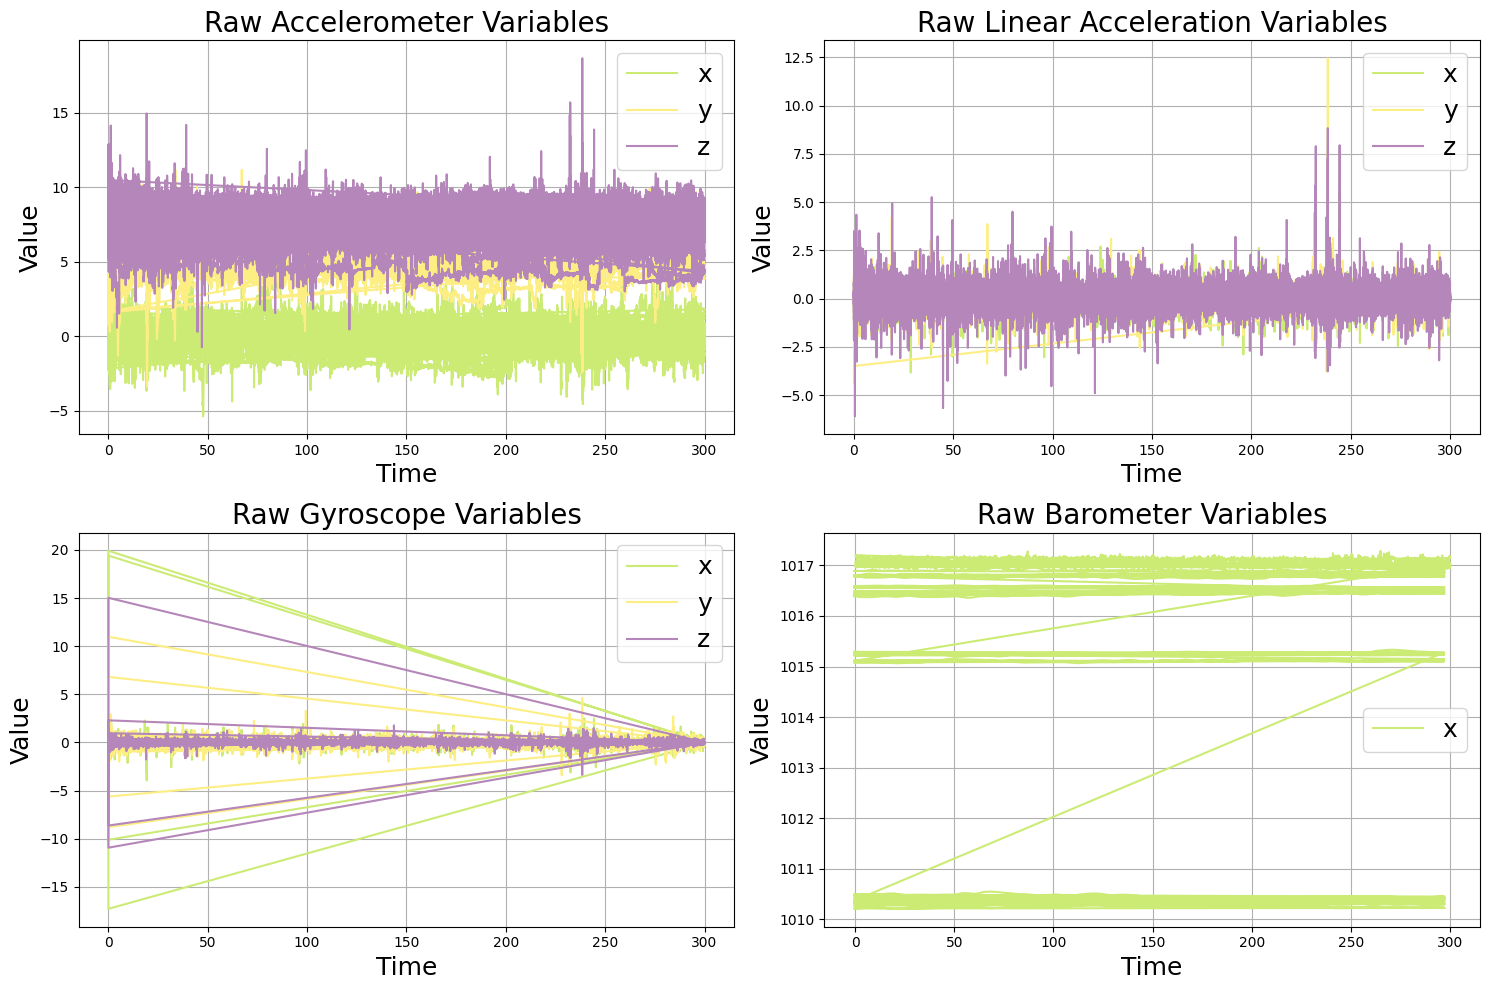

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for aesthetics

# Example datasets and dataset names (replace with your actual data)
datasets = [accel, lin_accel, gyro, baro]
dataset_names = ['Raw Accelerometer Variables', 'Raw Linear Acceleration Variables', 'Raw Gyroscope Variables', 'Raw Barometer Variables']

# Create a larger figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Define custom color palette with green from Set3, light yellow, and purple
custom_colors_swapped_final = [(0.8, 0.922, 0.459), (0.988, 0.933, 0.515), (0.706, 0.524, 0.727)]
columns = ['x', 'y', 'z']

# Loop through datasets and plot each variable with separate lines on subplots
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    for j, col in enumerate(columns):
        if col in data.columns:
            data[col].plot(ax=axs[i // 2, i % 2], color=custom_colors_swapped_final[j], label=f"{col}")
    axs[i // 2, i % 2].set_title(name, fontsize=20) #Add title with larger font size 
    axs[i // 2, i % 2].legend(fontsize=18)  # Add legend with larger font size
    axs[i // 2, i % 2].grid(True)  # Add gridlines (optional)
    axs[i // 2, i % 2].set_xlabel('Time', fontsize=18)  # Label x-axis with larger font size
    axs[i // 2, i % 2].set_ylabel('Value', fontsize=18)  # Label y-axis with larger font size

# Adjust layout
plt.tight_layout()

# Optional: Add a y-axis label if applicable to all datasets
# plt.ylabel('Measurement Value')  # Uncomment if applicable

plt.show()


/tmp/ipykernel_686/3666117154.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


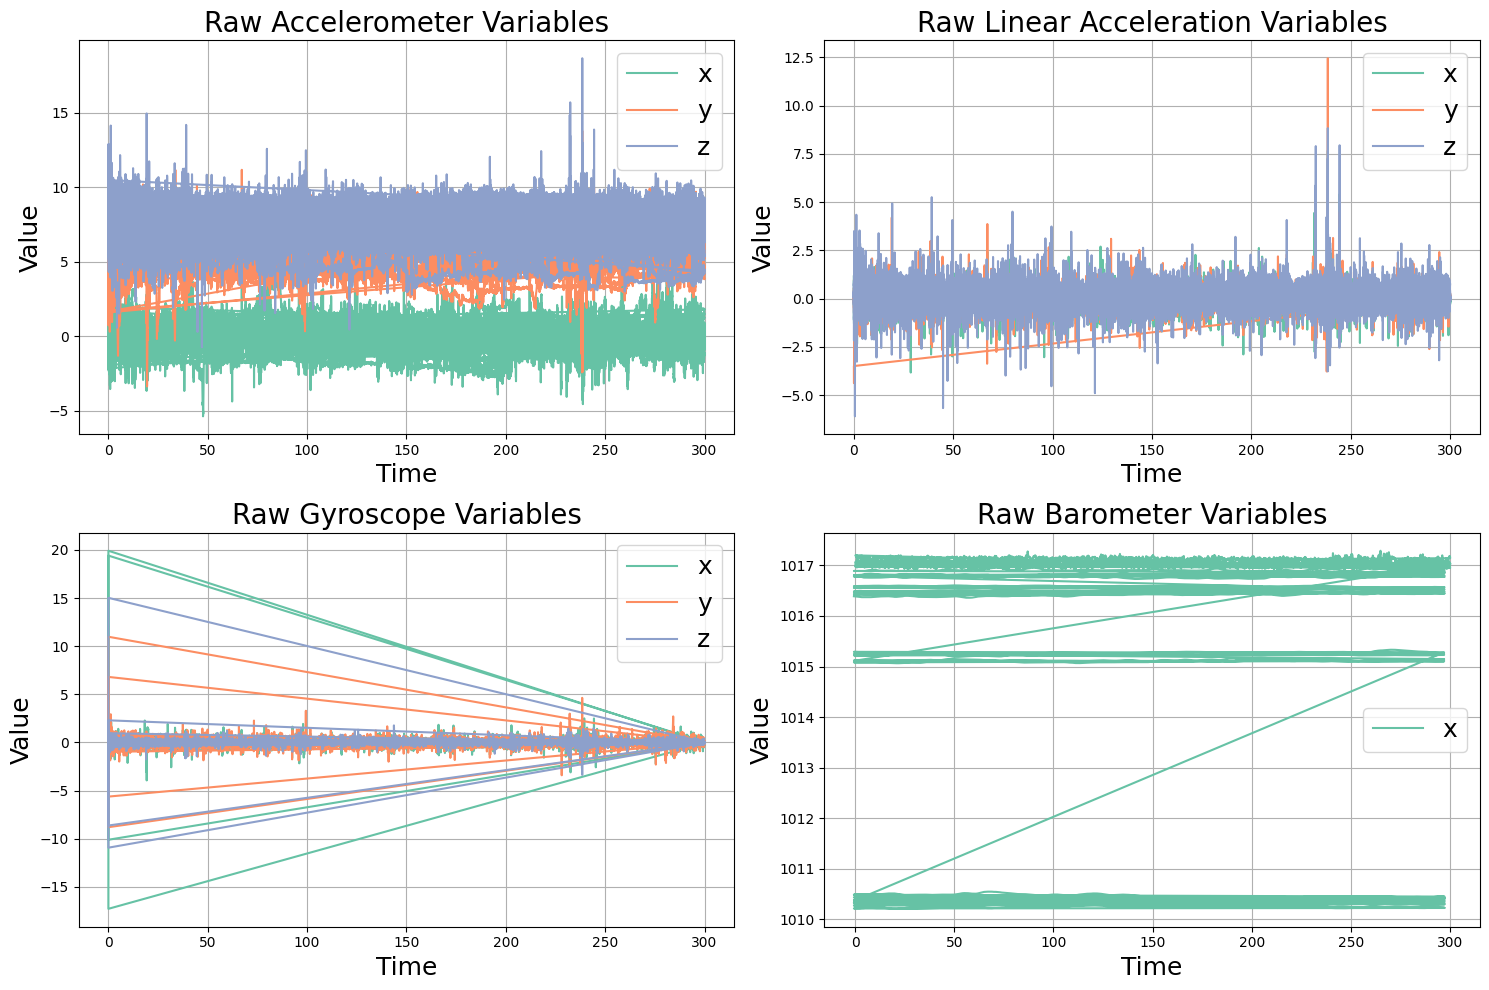

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for aesthetics

# Example datasets and dataset names (replace with your actual data)
datasets = [accel, lin_accel, gyro, baro]
dataset_names = ['Raw Accelerometer Variables', 'Raw Linear Acceleration Variables', 'Raw Gyroscope Variables', 'Raw Barometer Variables']

# Create a larger figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Define color palette from Set2 with 3 distinct colors for x, y, z
color_palette = sns.color_palette("Set2", n_colors=3)
columns = ['x', 'y', 'z']

# Loop through datasets and plot each variable with separate lines on subplots
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    for j, col in enumerate(columns):
        if col in data.columns:
            data[col].plot(ax=axs[i // 2, i % 2], color=color_palette[j], label=f"{col}")
    axs[i // 2, i % 2].set_title(name, fontsize=20)  # Add title with larger font size
    axs[i // 2, i % 2].legend(fontsize=18)  # Add legend with larger font size
    axs[i // 2, i % 2].grid(True)  # Add gridlines (optional)
    axs[i // 2, i % 2].set_xlabel('Time', fontsize=18)  # Label x-axis with larger font size
    axs[i // 2, i % 2].set_ylabel('Value', fontsize=18)  # Label y-axis with larger font size

# Adjust layout
plt.tight_layout()

# Optional: Add a y-axis label if applicable to all datasets
# plt.ylabel('Measurement Value')  # Uncomment if applicable

plt.show()


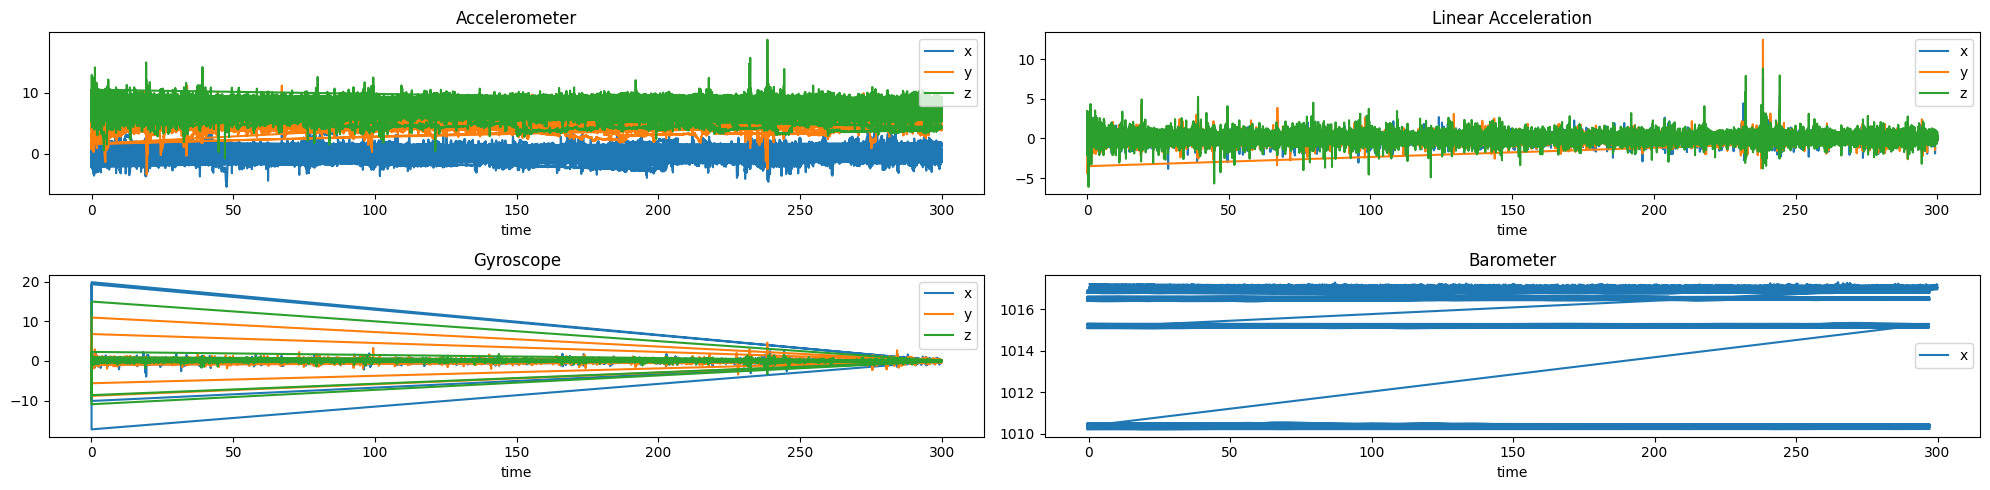

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(20, 5))

accel.plot(ax=axs[0,0])
axs[0,0].set_title('Accelerometer')

lin_accel.plot(ax=axs[0,1])
axs[0,1].set_title('Linear Acceleration')

# Plot dataset3 on the third subplot
gyro.plot(ax=axs[1,0])
axs[1,0].set_title('Gyroscope')

# Plot dataset4 on the fourth subplot
baro.plot(ax=axs[1,1])
axs[1,1].set_title('Barometer')

plt.tight_layout()

# PCA (Figure 5)

In [16]:
full_data = pd.read_parquet("full_dataset.parquet.gzip")

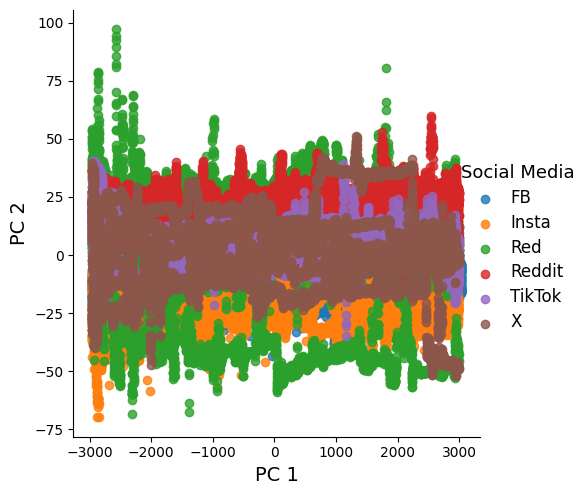

In [17]:
ax = sns.lmplot(x='pc_1', y='pc_2', data=full_data, 
                hue='SM_platform', fit_reg=False)

#plt.title('Most Important Two Principal Components in the Data')
ax.set_xlabels("PC 1",  fontsize=14)
ax.set_ylabels("PC 2",  fontsize=14)
ax._legend.set_title("Social Media")
plt.setp(ax._legend.get_texts(), fontsize=12)  # for legend text
plt.setp(ax._legend.get_title(), fontsize=13)  # for legend title

# Show the plot
plt.show()

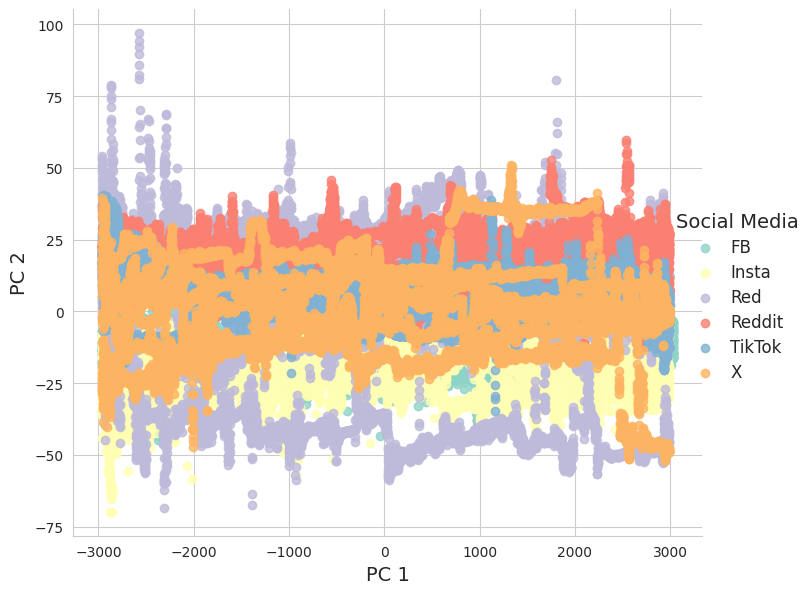

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create the scatter plot with principal components using the Set2 color palette
ax = sns.lmplot(x='pc_1', y='pc_2', data=full_data, 
                hue='SM_platform', fit_reg=False, 
                palette="Set3", height=6, aspect=1.2)

# Customize the title and labels
#plt.title('Most Important Two Principal Components in the Data', fontsize=16)
ax.set_xlabels("PC 1", fontsize=14)
ax.set_ylabels("PC 2", fontsize=14)
ax._legend.set_title("Social Media")
plt.setp(ax._legend.get_texts(), fontsize=12)  # for legend text
plt.setp(ax._legend.get_title(), fontsize=14)  # for legend title

# Show the plot
plt.show()


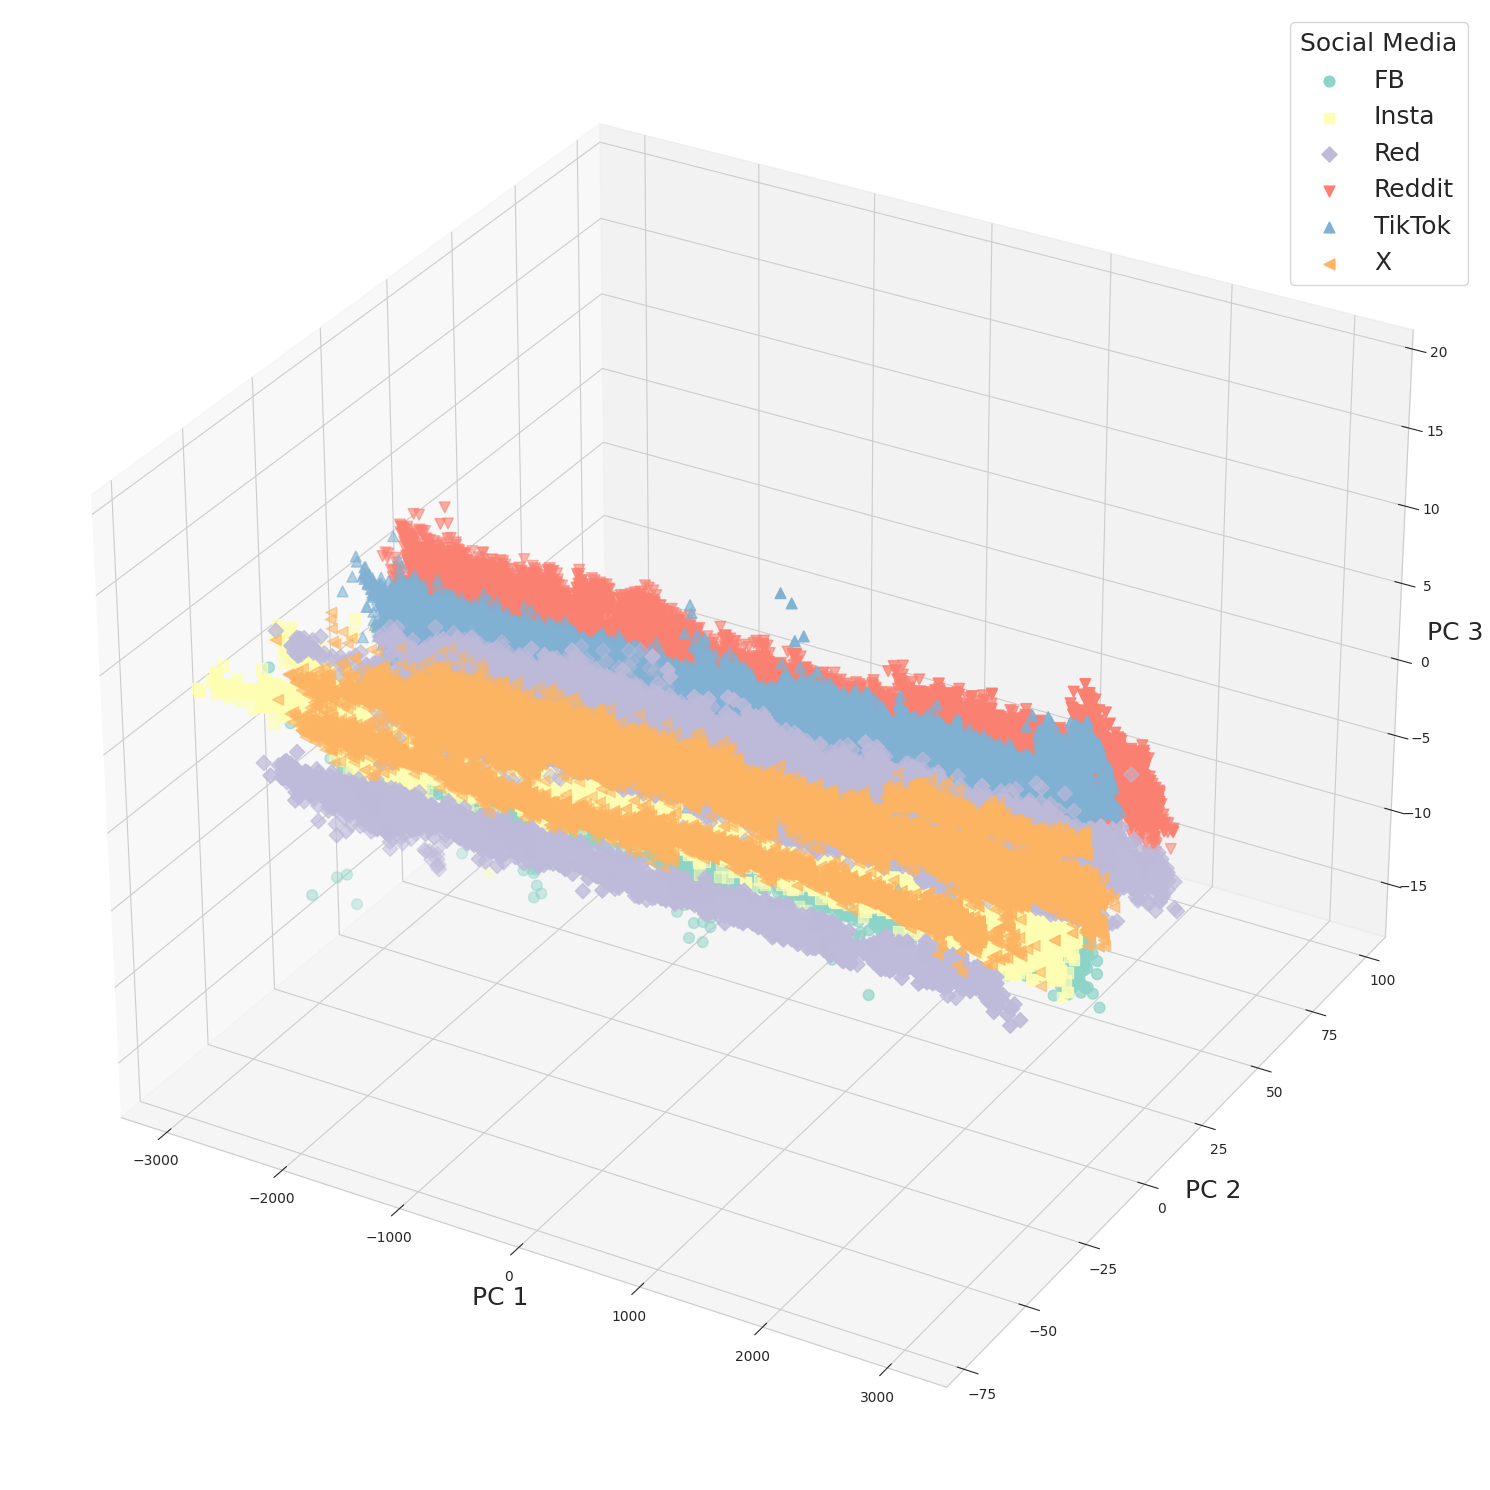

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Extracting the components and the hue variable
x = full_data['pc_1']
y = full_data['pc_2']
z = full_data['pc_3']  # Assuming there's a third principal component
hue = full_data['SM_platform']

# Determine the unique values in the hue variable and assign colors and markers
unique_platforms = full_data['SM_platform'].unique()
markers = ['o', 's', 'D', 'v', '^', '<', '>', 'p', 'P', '*', 'H', 'X', 'd']
chosen_markers = markers[:len(unique_platforms)]
colors = sns.color_palette("Set3", len(unique_platforms))

# Create a dictionary for platform to color and marker mapping
platform_to_color = {platform: colors[i] for i, platform in enumerate(unique_platforms)}
platform_to_marker = {platform: chosen_markers[i] for i, platform in enumerate(unique_platforms)}

# Initialize the 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each platform category with its corresponding color and marker
for platform in unique_platforms:
    indices = full_data['SM_platform'] == platform
    ax.scatter(x[indices], y[indices], z[indices], 
               c=np.array([platform_to_color[platform]]), 
               marker=platform_to_marker[platform], 
               label=platform, s=60)  # Adjust s for marker size if needed

# Customize the title and labels
#ax.set_title('Most Important Three Principal Components in the Data', fontsize=16)
ax.set_xlabel("PC 1", fontsize=18)
ax.set_ylabel("PC 2", fontsize=18)
ax.set_zlabel("PC 3", fontsize=18)
ax.legend(title="Social Media", fontsize=18, title_fontsize=18)

# Adjust layout to ensure labels are visible
plt.subplots_adjust(left=0.1, right=2.2, top=2.2, bottom=0.1)

# Show the plot
plt.show()


# Descriptive Statistics (Figure 1)

## Accelerometer

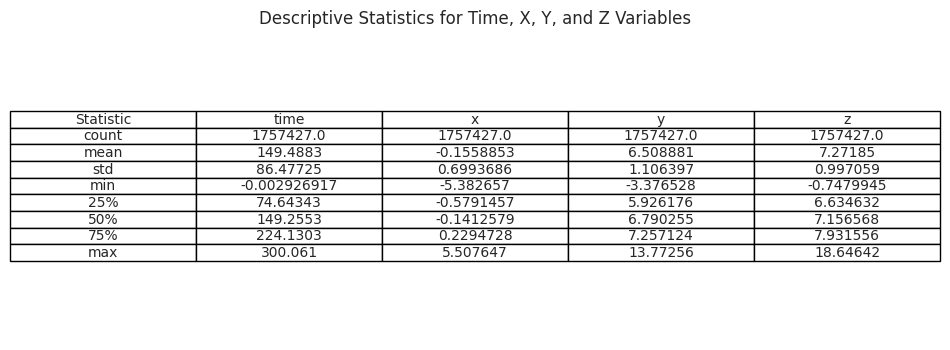

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the data
data = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757427e+06, 1.494883e+02, 8.647725e+01, -2.926917e-03, 7.464343e+01, 1.492553e+02, 2.241303e+02, 3.000610e+02],
    "x": [1.757427e+06, -1.558853e-01, 6.993686e-01, -5.382657e+00, -5.791457e-01, -1.412579e-01, 2.294728e-01, 5.507647e+00],
    "y": [1.757427e+06, 6.508881e+00, 1.106397e+00, -3.376528e+00, 5.926176e+00, 6.790255e+00, 7.257124e+00, 1.377256e+01],
    "z": [1.757427e+06, 7.271850e+00, 9.970590e-01, -7.479945e-01, 6.634632e+00, 7.156568e+00, 7.931556e+00, 1.864642e+01]
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the table
fig, ax = plt.subplots(figsize=(12, 4))  # set size frame
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Displaying the table
plt.title('Descriptive Statistics for Time, X, Y, and Z Variables')
plt.show()


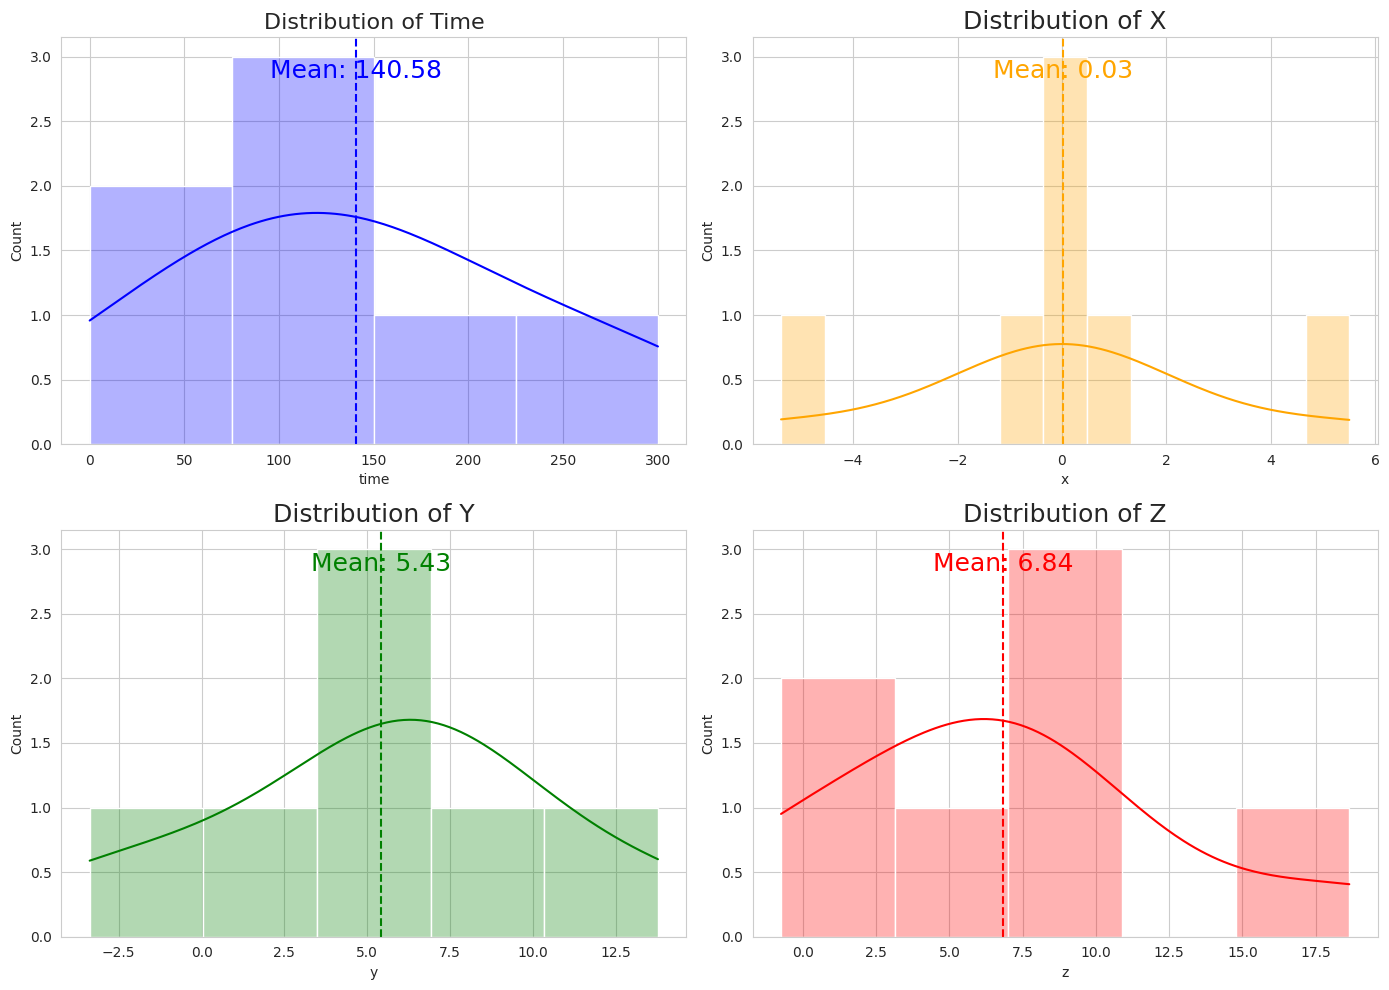

In [71]:
#Dataset 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the data
data = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757427e+06, 1.494883e+02, 8.647725e+01, -2.926917e-03, 7.464343e+01, 1.492553e+02, 2.241303e+02, 3.000610e+02],
    "x": [1.757427e+06, -1.558853e-01, 6.993686e-01, -5.382657e+00, -5.791457e-01, -1.412579e-01, 2.294728e-01, 5.507647e+00],
    "y": [1.757427e+06, 6.508881e+00, 1.106397e+00, -3.376528e+00, 5.926176e+00, 6.790255e+00, 7.257124e+00, 1.377256e+01],
    "z": [1.757427e+06, 7.271850e+00, 9.970590e-01, -7.479945e-01, 6.634632e+00, 7.156568e+00, 7.931556e+00, 1.864642e+01]
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Extracting values for plotting (excluding the 'count' statistic)
time_values = df[df['Statistic'] != 'count']['time'].astype(float)
x_values = df[df['Statistic'] != 'count']['x'].astype(float)
y_values = df[df['Statistic'] != 'count']['y'].astype(float)
z_values = df[df['Statistic'] != 'count']['z'].astype(float)

# Creating the plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for 'time'
sns.histplot(time_values, kde=True, ax=axs[0, 0], color='blue', alpha=0.3)
axs[0, 0].axvline(time_values.mean(), color='blue', linestyle='--')
axs[0, 0].text(time_values.mean(), max(axs[0, 0].get_ylim())*0.9, f'Mean: {time_values.mean():.2f}', color='blue', ha='center', fontsize=18)
axs[0, 0].set_title('Distribution of Time', fontsize=16)

# Plot for 'x'
sns.histplot(x_values, kde=True, ax=axs[0, 1], color='orange', alpha=0.3)
axs[0, 1].axvline(x_values.mean(), color='orange', linestyle='--')
axs[0, 1].text(x_values.mean(), max(axs[0, 1].get_ylim())*0.9, f'Mean: {x_values.mean():.2f}', color='orange', ha='center', fontsize=18)
axs[0, 1].set_title('Distribution of X', fontsize=18)

# Plot for 'y'
sns.histplot(y_values, kde=True, ax=axs[1, 0], color='green', alpha=0.3)
axs[1, 0].axvline(y_values.mean(), color='green', linestyle='--')
axs[1, 0].text(y_values.mean(), max(axs[1, 0].get_ylim())*0.9, f'Mean: {y_values.mean():.2f}', color='green', ha='center', fontsize=18)
axs[1, 0].set_title('Distribution of Y', fontsize=18)

# Plot for 'z'
sns.histplot(z_values, kde=True, ax=axs[1, 1], color='red', alpha=0.3)
axs[1, 1].axvline(z_values.mean(), color='red', linestyle='--')
axs[1, 1].text(z_values.mean(), max(axs[1, 1].get_ylim())*0.9, f'Mean: {z_values.mean():.2f}', color='red', ha='center', fontsize=18)
axs[1, 1].set_title('Distribution of Z', fontsize=18)

plt.tight_layout()
plt.show()


## Linear Acceleration 

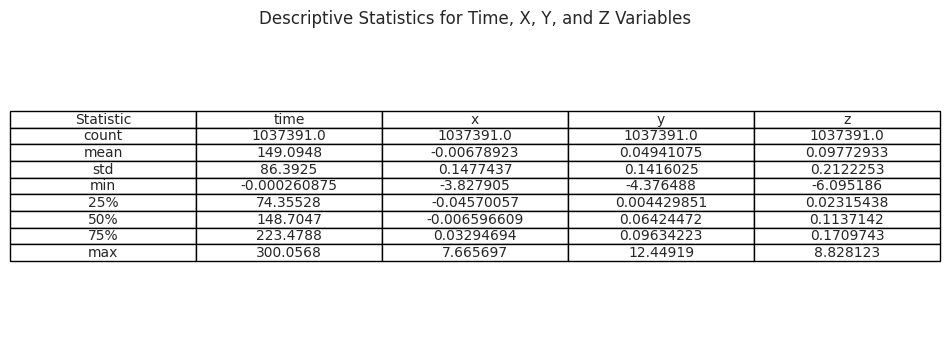

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the data
data = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.037391e+06, 1.490948e+02, 8.639250e+01, -2.608750e-04, 7.435528e+01, 1.487047e+02, 2.234788e+02, 3.000568e+02],
    "x": [1.037391e+06, -6.789230e-03, 1.477437e-01, -3.827905e+00, -4.570057e-02, -6.596609e-03, 3.294694e-02, 7.665697e+00],
    "y": [1.037391e+06, 4.941075e-02, 1.416025e-01, -4.376488e+00, 4.429851e-03, 6.424472e-02, 9.634223e-02, 1.244919e+01],
    "z": [1.037391e+06, 9.772933e-02, 2.122253e-01, -6.095186e+00, 2.315438e-02, 1.137142e-01, 1.709743e-01, 8.828123e+00]
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the table
fig, ax = plt.subplots(figsize=(12, 4))  # set size frame
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Displaying the table
plt.title('Descriptive Statistics for Time, X, Y, and Z Variables')
plt.show()


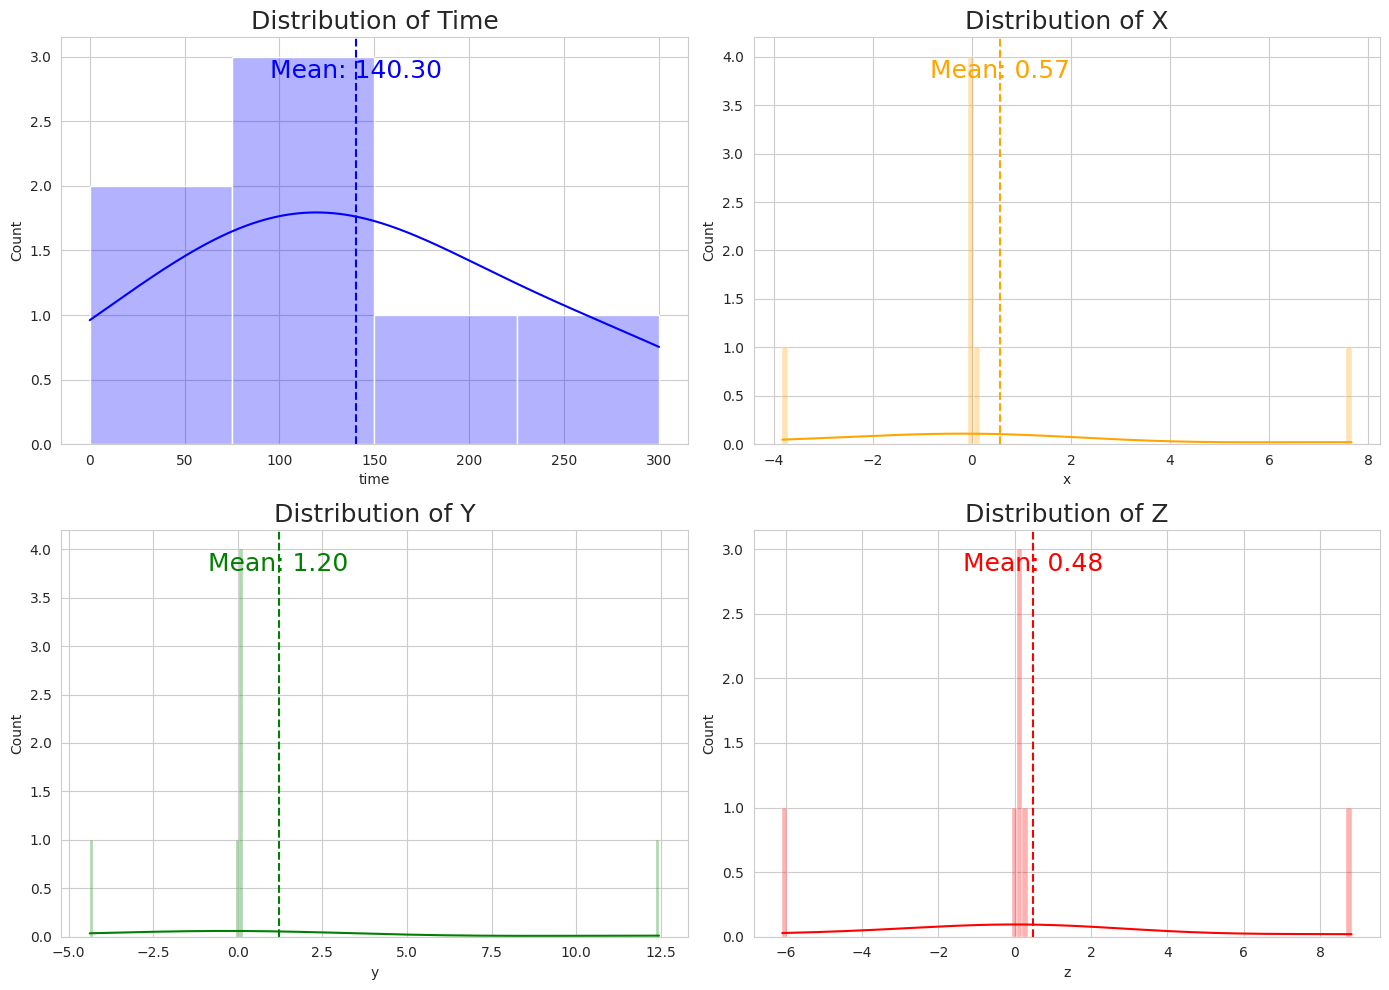

In [72]:
#Dataset 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the data for the first dataset
data1 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.037391e+06, 1.490948e+02, 8.639250e+01, -2.608750e-04, 7.435528e+01, 1.487047e+02, 2.234788e+02, 3.000568e+02],
    "x": [1.037391e+06, -6.789230e-03, 1.477437e-01, -3.827905e+00, -4.570057e-02, -6.596609e-03, 3.294694e-02, 7.665697e+00],
    "y": [1.037391e+06, 4.941075e-02, 1.416025e-01, -4.376488e+00, 4.429851e-03, 6.424472e-02, 9.634223e-02, 1.244919e+01],
    "z": [1.037391e+06, 9.772933e-02, 2.122253e-01, -6.095186e+00, 2.315438e-02, 1.137142e-01, 1.709743e-01, 8.828123e+00]
}

# Creating the DataFrame
df1 = pd.DataFrame(data1)

# Extracting values for plotting (excluding the 'count' statistic)
time_values1 = df1[df1['Statistic'] != 'count']['time'].astype(float)
x_values1 = df1[df1['Statistic'] != 'count']['x'].astype(float)
y_values1 = df1[df1['Statistic'] != 'count']['y'].astype(float)
z_values1 = df1[df1['Statistic'] != 'count']['z'].astype(float)

# Creating the plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for 'time'
sns.histplot(time_values1, kde=True, ax=axs[0, 0], color='blue', alpha=0.3)
axs[0, 0].axvline(time_values1.mean(), color='blue', linestyle='--')
axs[0, 0].text(time_values1.mean(), max(axs[0, 0].get_ylim())*0.9, f'Mean: {time_values1.mean():.2f}', color='blue', ha='center', fontsize=18)
axs[0, 0].set_title('Distribution of Time', fontsize=18)

# Plot for 'x'
sns.histplot(x_values1, kde=True, ax=axs[0, 1], color='orange', alpha=0.3)
axs[0, 1].axvline(x_values1.mean(), color='orange', linestyle='--')
axs[0, 1].text(x_values1.mean(), max(axs[0, 1].get_ylim())*0.9, f'Mean: {x_values1.mean():.2f}', color='orange', ha='center', fontsize=18)
axs[0, 1].set_title('Distribution of X', fontsize=18)

# Plot for 'y'
sns.histplot(y_values1, kde=True, ax=axs[1, 0], color='green', alpha=0.3)
axs[1, 0].axvline(y_values1.mean(), color='green', linestyle='--')
axs[1, 0].text(y_values1.mean(), max(axs[1, 0].get_ylim())*0.9, f'Mean: {y_values1.mean():.2f}', color='green', ha='center', fontsize=18)
axs[1, 0].set_title('Distribution of Y', fontsize=18)

# Plot for 'z'
sns.histplot(z_values1, kde=True, ax=axs[1, 1], color='red', alpha=0.3)
axs[1, 1].axvline(z_values1.mean(), color='red', linestyle='--')
axs[1, 1].text(z_values1.mean(), max(axs[1, 1].get_ylim())*0.9, f'Mean: {z_values1.mean():.2f}', color='red', ha='center', fontsize=18)
axs[1, 1].set_title('Distribution of Z', fontsize=18)

plt.tight_layout()
plt.show()


## Gyroscope 

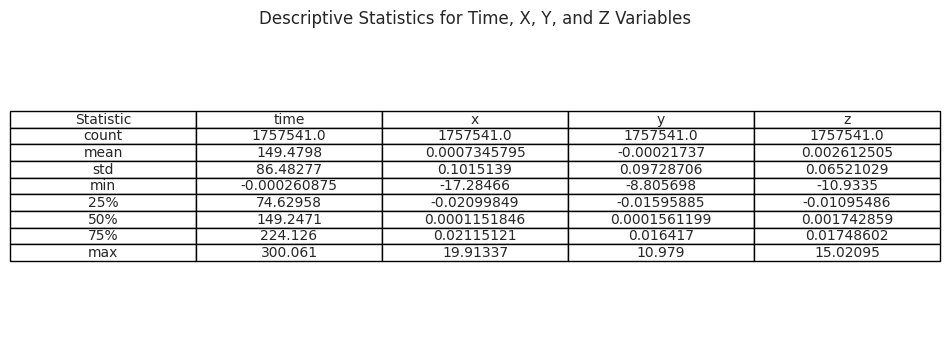

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the data
data = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757541e+06, 1.494798e+02, 8.648277e+01, -2.608750e-04, 7.462958e+01, 1.492471e+02, 2.241260e+02, 3.000610e+02],
    "x": [1.757541e+06, 7.345795e-04, 1.015139e-01, -1.728466e+01, -2.099849e-02, 1.151846e-04, 2.115121e-02, 1.991337e+01],
    "y": [1.757541e+06, -2.173700e-04, 9.728706e-02, -8.805698e+00, -1.595885e-02, 1.561199e-04, 1.641700e-02, 1.097900e+01],
    "z": [1.757541e+06, 2.612505e-03, 6.521029e-02, -1.093350e+01, -1.095486e-02, 1.742859e-03, 1.748602e-02, 1.502095e+01]
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the table
fig, ax = plt.subplots(figsize=(12, 4))  # set size frame
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Displaying the table
plt.title('Descriptive Statistics for Time, X, Y, and Z Variables')
plt.show()


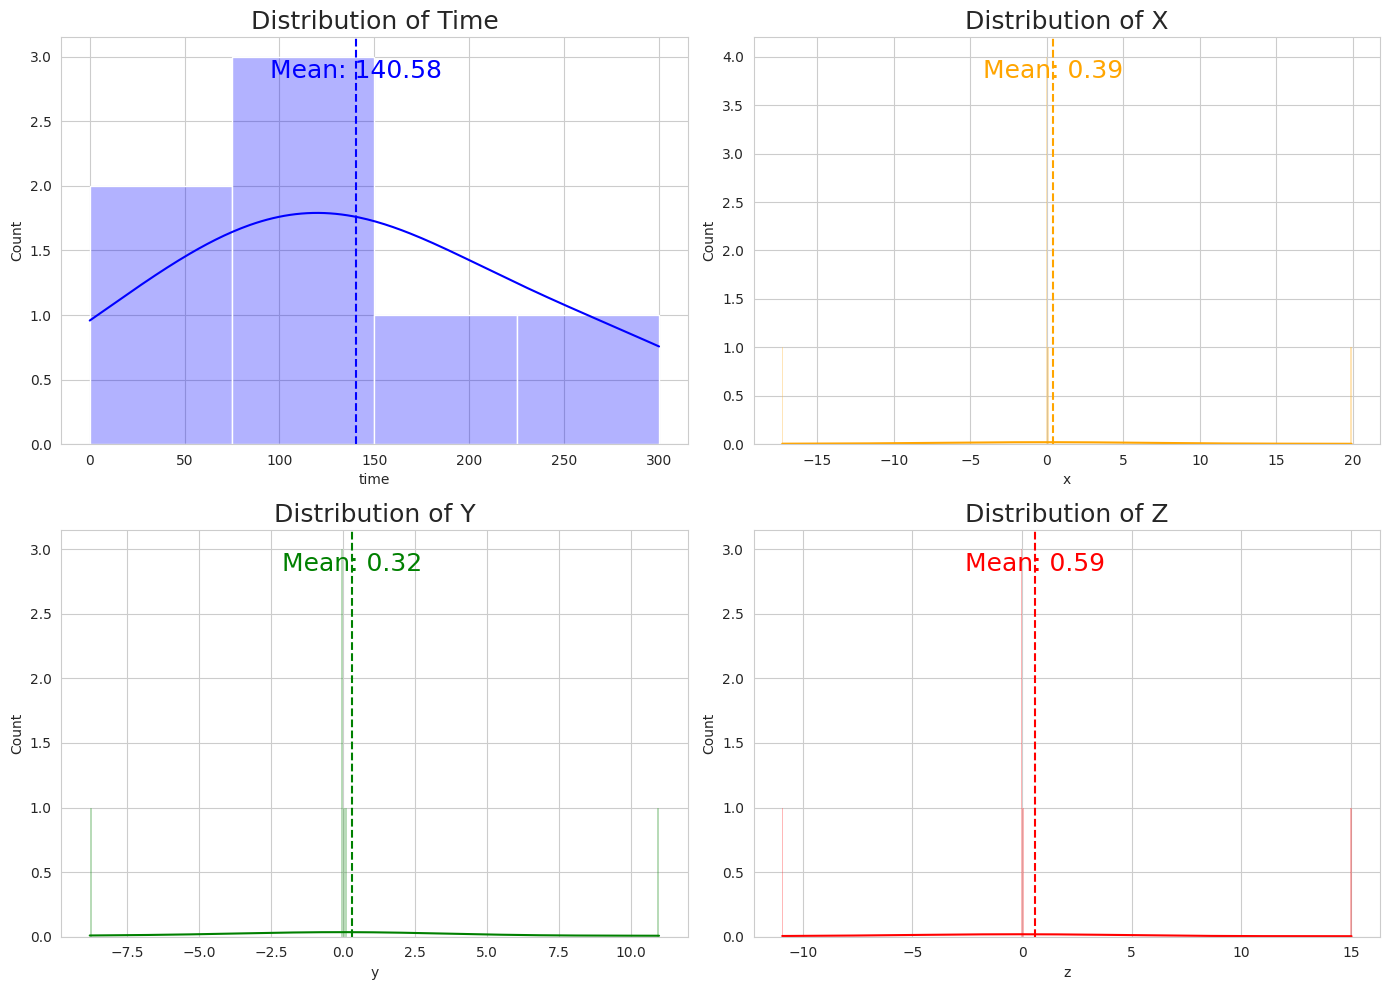

In [73]:
#Dataset 3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the data for the second dataset
data2 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757541e+06, 1.494798e+02, 8.648277e+01, -2.608750e-04, 7.462958e+01, 1.492471e+02, 2.241260e+02, 3.000610e+02],
    "x": [1.757541e+06, 7.345795e-04, 1.015139e-01, -1.728466e+01, -2.099849e-02, 1.151846e-04, 2.115121e-02, 1.991337e+01],
    "y": [1.757541e+06, -2.173700e-04, 9.728706e-02, -8.805698e+00, -1.595885e-02, 1.561199e-04, 1.641700e-02, 1.097900e+01],
    "z": [1.757541e+06, 2.612505e-03, 6.521029e-02, -1.093350e+01, -1.095486e-02, 1.742859e-03, 1.748602e-02, 1.502095e+01]
}

# Creating the DataFrame
df2 = pd.DataFrame(data2)

# Extracting values for plotting (excluding the 'count' statistic)
time_values2 = df2[df2['Statistic'] != 'count']['time'].astype(float)
x_values2 = df2[df2['Statistic'] != 'count']['x'].astype(float)
y_values2 = df2[df2['Statistic'] != 'count']['y'].astype(float)
z_values2 = df2[df2['Statistic'] != 'count']['z'].astype(float)

# Creating the plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for 'time'
sns.histplot(time_values2, kde=True, ax=axs[0, 0], color='blue', alpha=0.3)
axs[0, 0].axvline(time_values2.mean(), color='blue', linestyle='--')
axs[0, 0].text(time_values2.mean(), max(axs[0, 0].get_ylim())*0.9, f'Mean: {time_values2.mean():.2f}', color='blue', ha='center', fontsize=18)
axs[0, 0].set_title('Distribution of Time', fontsize=18)

# Plot for 'x'
sns.histplot(x_values2, kde=True, ax=axs[0, 1], color='orange', alpha=0.3)
axs[0, 1].axvline(x_values2.mean(), color='orange', linestyle='--')
axs[0, 1].text(x_values2.mean(), max(axs[0, 1].get_ylim())*0.9, f'Mean: {x_values2.mean():.2f}', color='orange', ha='center', fontsize=18)
axs[0, 1].set_title('Distribution of X', fontsize=18)

# Plot for 'y'
sns.histplot(y_values2, kde=True, ax=axs[1, 0], color='green', alpha=0.3)
axs[1, 0].axvline(y_values2.mean(), color='green', linestyle='--')
axs[1, 0].text(y_values2.mean(), max(axs[1, 0].get_ylim())*0.9, f'Mean: {y_values2.mean():.2f}', color='green', ha='center', fontsize=18)
axs[1, 0].set_title('Distribution of Y', fontsize=18)

# Plot for 'z'
sns.histplot(z_values2, kde=True, ax=axs[1, 1], color='red', alpha=0.3)
axs[1, 1].axvline(z_values2.mean(), color='red', linestyle='--')
axs[1, 1].text(z_values2.mean(), max(axs[1, 1].get_ylim())*0.9, f'Mean: {z_values2.mean():.2f}', color='red', ha='center', fontsize=18)
axs[1, 1].set_title('Distribution of Z', fontsize=18)

plt.tight_layout()
plt.show()


## Barometer

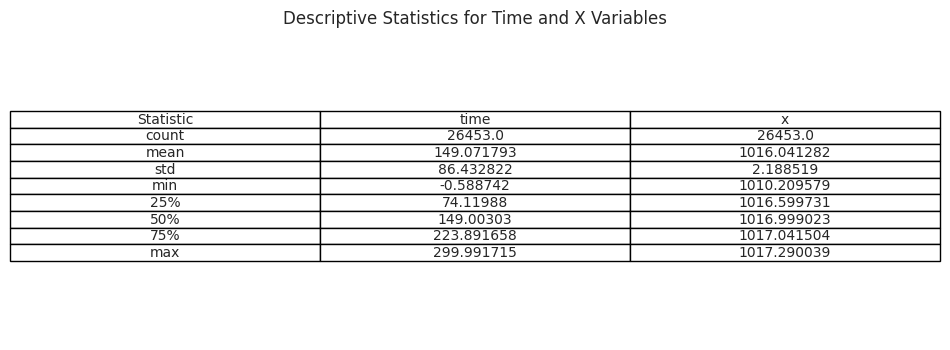

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Creating the data
data = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [26453.000000, 149.071793, 86.432822, -0.588742, 74.119880, 149.003030, 223.891658, 299.991715],
    "x": [26453.000000, 1016.041282, 2.188519, 1010.209579, 1016.599731, 1016.999023, 1017.041504, 1017.290039]
}

# Creating the DataFrame
df = pd.DataFrame(data)

# Plotting the table
fig, ax = plt.subplots(figsize=(12, 4))  # set size frame
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center')

# Displaying the table
plt.title('Descriptive Statistics for Time and X Variables')
plt.show()


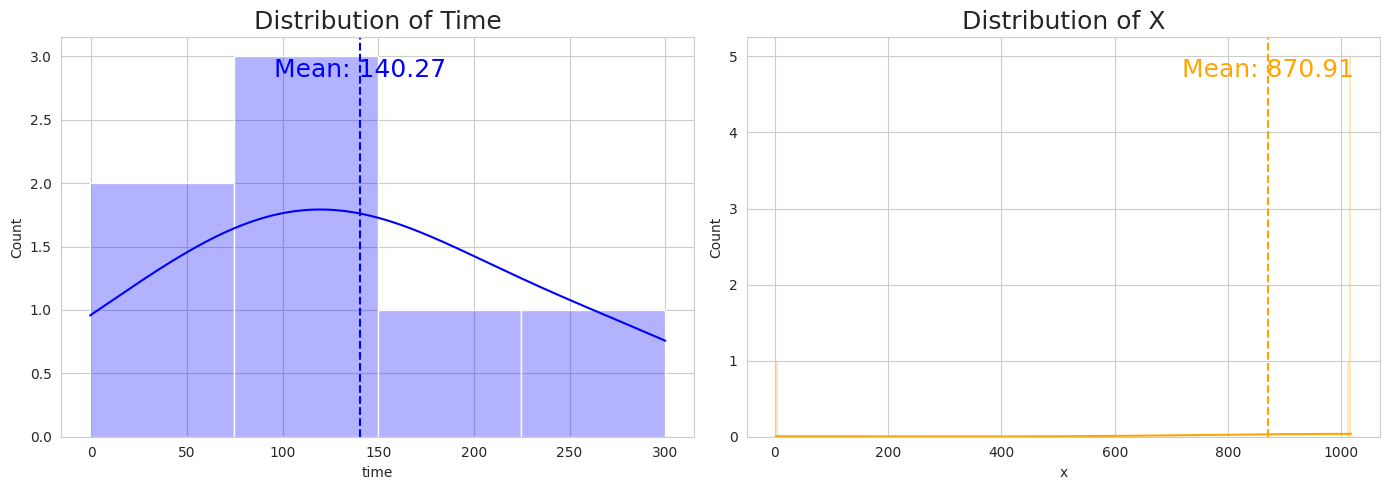

In [74]:
#Datset 4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the data for the third dataset
data3 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [26453.000000, 149.071793, 86.432822, -0.588742, 74.119880, 149.003030, 223.891658, 299.991715],
    "x": [26453.000000, 1016.041282, 2.188519, 1010.209579, 1016.599731, 1016.999023, 1017.041504, 1017.290039]
}

# Creating the DataFrame
df3 = pd.DataFrame(data3)

# Extracting values for plotting (excluding the 'count' statistic)
time_values3 = df3[df3['Statistic'] != 'count']['time'].astype(float)
x_values3 = df3[df3['Statistic'] != 'count']['x'].astype(float)

# Creating the plots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot for 'time'
sns.histplot(time_values3, kde=True, ax=axs[0], color='blue', alpha=0.3)
axs[0].axvline(time_values3.mean(), color='blue', linestyle='--')
axs[0].text(time_values3.mean(), max(axs[0].get_ylim())*0.9, f'Mean: {time_values3.mean():.2f}', color='blue', ha='center', fontsize=18)
axs[0].set_title('Distribution of Time', fontsize=18)

# Plot for 'x'
sns.histplot(x_values3, kde=True, ax=axs[1], color='orange', alpha=0.3)
axs[1].axvline(x_values3.mean(), color='orange', linestyle='--')
axs[1].text(x_values3.mean(), max(axs[1].get_ylim())*0.9, f'Mean: {x_values3.mean():.2f}', color='orange', ha='center', fontsize=18)
axs[1].set_title('Distribution of X', fontsize=18)

plt.tight_layout()
plt.show()


## Combined Visualization of the 4 Variables (Accelerometer/ Linear Acceleration/Gyroscope/Barometer)

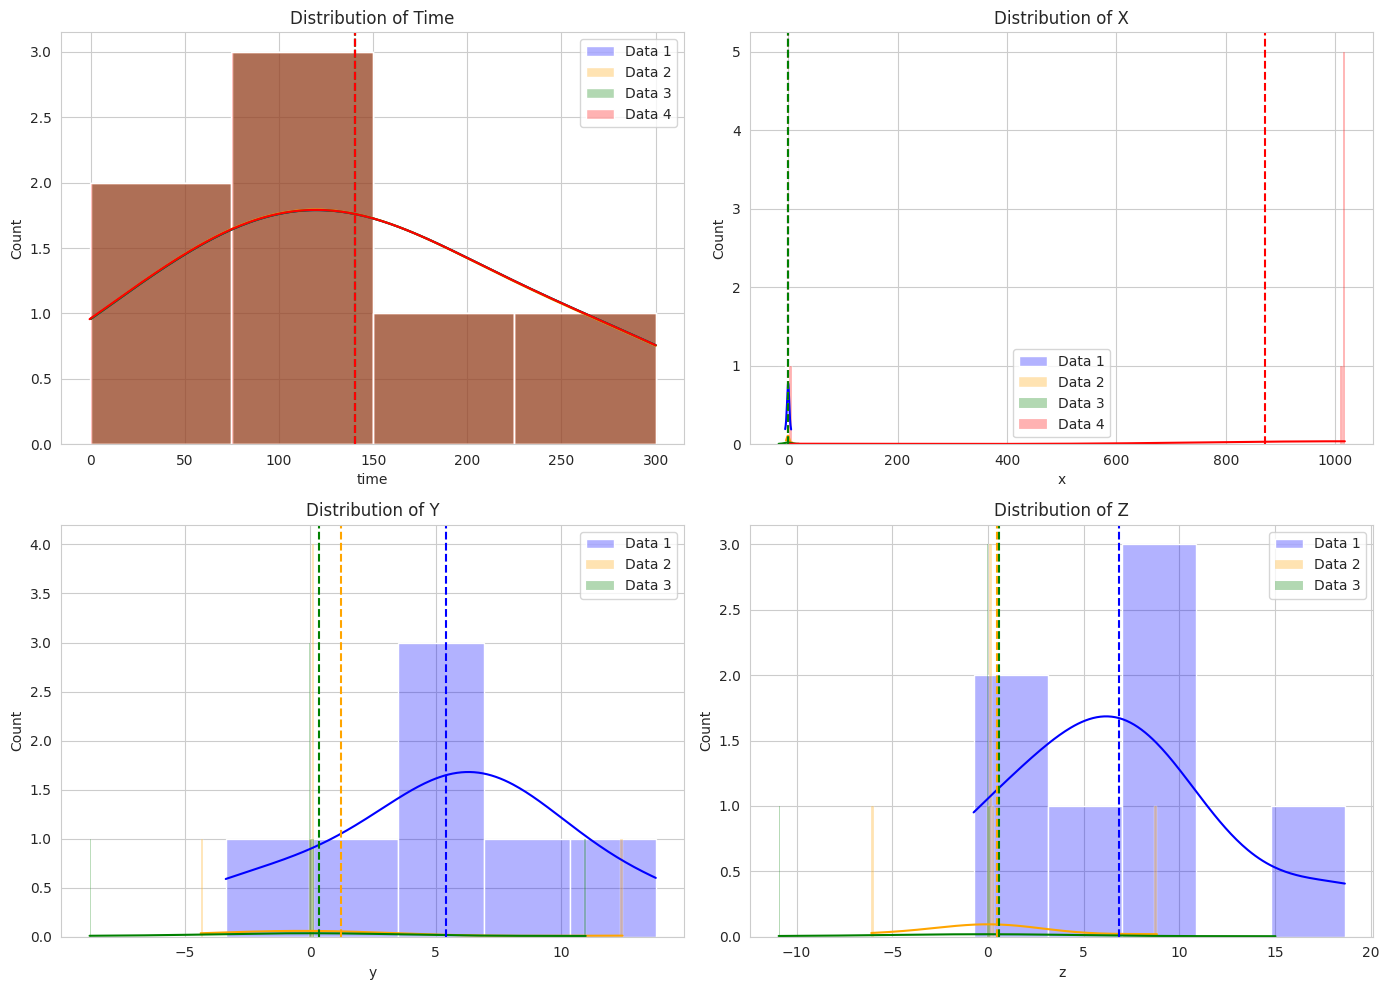

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data 1
data1 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757427e+06, 1.494883e+02, 8.647725e+01, -2.926917e-03, 7.464343e+01, 1.492553e+02, 2.241303e+02, 3.000610e+02],
    "x": [1.757427e+06, -1.558853e-01, 6.993686e-01, -5.382657e+00, -5.791457e-01, -1.412579e-01, 2.294728e-01, 5.507647e+00],
    "y": [1.757427e+06, 6.508881e+00, 1.106397e+00, -3.376528e+00, 5.926176e+00, 6.790255e+00, 7.257124e+00, 1.377256e+01],
    "z": [1.757427e+06, 7.271850e+00, 9.970590e-01, -7.479945e-01, 6.634632e+00, 7.156568e+00, 7.931556e+00, 1.864642e+01]
}

# Data 2
data2 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.037391e+06, 1.490948e+02, 8.639250e+01, -2.608750e-04, 7.435528e+01, 1.487047e+02, 2.234788e+02, 3.000568e+02],
    "x": [1.037391e+06, -6.789230e-03, 1.477437e-01, -3.827905e+00, -4.570057e-02, -6.596609e-03, 3.294694e-02, 7.665697e+00],
    "y": [1.037391e+06, 4.941075e-02, 1.416025e-01, -4.376488e+00, 4.429851e-03, 6.424472e-02, 9.634223e-02, 1.244919e+01],
    "z": [1.037391e+06, 9.772933e-02, 2.122253e-01, -6.095186e+00, 2.315438e-02, 1.137142e-01, 1.709743e-01, 8.828123e+00]
}

# Data 3
data3 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [1.757541e+06, 1.494798e+02, 8.648277e+01, -2.608750e-04, 7.462958e+01, 1.492471e+02, 2.241260e+02, 3.000610e+02],
    "x": [1.757541e+06, 7.345795e-04, 1.015139e-01, -1.728466e+01, -2.099849e-02, 1.151846e-04, 2.115121e-02, 1.991337e+01],
    "y": [1.757541e+06, -2.173700e-04, 9.728706e-02, -8.805698e+00, -1.595885e-02, 1.561199e-04, 1.641700e-02, 1.097900e+01],
    "z": [1.757541e+06, 2.612505e-03, 6.521029e-02, -1.093350e+01, -1.095486e-02, 1.742859e-03, 1.748602e-02, 1.502095e+01]
}

# Data 4
data4 = {
    "Statistic": ["count", "mean", "std", "min", "25%", "50%", "75%", "max"],
    "time": [26453.000000, 149.071793, 86.432822, -0.588742, 74.119880, 149.003030, 223.891658, 299.991715],
    "x": [26453.000000, 1016.041282, 2.188519, 1010.209579, 1016.599731, 1016.999023, 1017.041504, 1017.290039]
}

# Creating DataFrames
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
df3 = pd.DataFrame(data3)
df4 = pd.DataFrame(data4)

# Extracting values for plotting (excluding the 'count' statistic)
time_values1 = df1[df1['Statistic'] != 'count']['time'].astype(float)
x_values1 = df1[df1['Statistic'] != 'count']['x'].astype(float)
y_values1 = df1[df1['Statistic'] != 'count']['y'].astype(float)
z_values1 = df1[df1['Statistic'] != 'count']['z'].astype(float)

time_values2 = df2[df2['Statistic'] != 'count']['time'].astype(float)
x_values2 = df2[df2['Statistic'] != 'count']['x'].astype(float)
y_values2 = df2[df2['Statistic'] != 'count']['y'].astype(float)
z_values2 = df2[df2['Statistic'] != 'count']['z'].astype(float)

time_values3 = df3[df3['Statistic'] != 'count']['time'].astype(float)
x_values3 = df3[df3['Statistic'] != 'count']['x'].astype(float)
y_values3 = df3[df3['Statistic'] != 'count']['y'].astype(float)
z_values3 = df3[df3['Statistic'] != 'count']['z'].astype(float)

time_values4 = df4[df4['Statistic'] != 'count']['time'].astype(float)
x_values4 = df4[df4['Statistic'] != 'count']['x'].astype(float)

# Creating the combined plots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for 'time'
sns.histplot(time_values1, kde=True, ax=axs[0, 0], color='blue', alpha=0.3, label='Data 1')
sns.histplot(time_values2, kde=True, ax=axs[0, 0], color='orange', alpha=0.3, label='Data 2')
sns.histplot(time_values3, kde=True, ax=axs[0, 0], color='green', alpha=0.3, label='Data 3')
sns.histplot(time_values4, kde=True, ax=axs[0, 0], color='red', alpha=0.3, label='Data 4')
axs[0, 0].axvline(time_values1.mean(), color='blue', linestyle='--')
axs[0, 0].axvline(time_values2.mean(), color='orange', linestyle='--')
axs[0, 0].axvline(time_values3.mean(), color='green', linestyle='--')
axs[0, 0].axvline(time_values4.mean(), color='red', linestyle='--')
axs[0, 0].set_title('Distribution of Time')
axs[0, 0].legend()

# Plot for 'x'
sns.histplot(x_values1, kde=True, ax=axs[0, 1], color='blue', alpha=0.3, label='Data 1')
sns.histplot(x_values2, kde=True, ax=axs[0, 1], color='orange', alpha=0.3, label='Data 2')
sns.histplot(x_values3, kde=True, ax=axs[0, 1], color='green', alpha=0.3, label='Data 3')
sns.histplot(x_values4, kde=True, ax=axs[0, 1], color='red', alpha=0.3, label='Data 4')
axs[0, 1].axvline(x_values1.mean(), color='blue', linestyle='--')
axs[0, 1].axvline(x_values2.mean(), color='orange', linestyle='--')
axs[0, 1].axvline(x_values3.mean(), color='green', linestyle='--')
axs[0, 1].axvline(x_values4.mean(), color='red', linestyle='--')
axs[0, 1].set_title('Distribution of X')
axs[0, 1].legend()

# Plot for 'y'
sns.histplot(y_values1, kde=True, ax=axs[1, 0], color='blue', alpha=0.3, label='Data 1')
sns.histplot(y_values2, kde=True, ax=axs[1, 0], color='orange', alpha=0.3, label='Data 2')
sns.histplot(y_values3, kde=True, ax=axs[1, 0], color='green', alpha=0.3, label='Data 3')
axs[1, 0].axvline(y_values1.mean(), color='blue', linestyle='--')
axs[1, 0].axvline(y_values2.mean(), color='orange', linestyle='--')
axs[1, 0].axvline(y_values3.mean(), color='green', linestyle='--')
axs[1, 0].set_title('Distribution of Y')
axs[1, 0].legend()

# Plot for 'z'
sns.histplot(z_values1, kde=True, ax=axs[1, 1], color='blue', alpha=0.3, label='Data 1')
sns.histplot(z_values2, kde=True, ax=axs[1, 1], color='orange', alpha=0.3, label='Data 2')
sns.histplot(z_values3, kde=True, ax=axs[1, 1], color='green', alpha=0.3, label='Data 3')
axs[1, 1].axvline(z_values1.mean(), color='blue', linestyle='--')
axs[1, 1].axvline(z_values2.mean(), color='orange', linestyle='--')
axs[1, 1].axvline(z_values3.mean(), color='green', linestyle='--')
axs[1, 1].set_title('Distribution of Z')
axs[1, 1].legend()

plt.tight_layout()
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5ea8f536-739f-4c50-806e-84490cb7d5e0' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

# Principal Component Analysis (PCA)

# Dimension Reduction - PCA

## Read Parquet File 

In [ ]:
!pip install pyarrow

!pip install fastparquet



[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import pyarrow
import fastparquet

In [ ]:
# Reading the Parquet file
test = "Final Dataset.gzip"  # Updated the path to the actual file
df_test = pd.read_parquet(test)  # Use read_parquet to read a Parquet file
print(df_test.head())


   time_accel  accel_x_max  accel_y_max  accel_z_max  accel_inclination_max  \
0    0.069037    -0.691924     7.451055     7.340922              46.477479   
1    0.119037    -0.948104     7.884406     7.132626              51.369980   
2    0.169037    -0.909797     7.872435     7.537246              48.013635   
3    0.219037    -0.502782     7.245153     7.455843              46.192832   
4    0.269037    -0.141258     6.749554     6.897995              49.132363   

   accel_zscore_x_max  accel_zscore_y_max  accel_zscore_z_max  \
0           -0.164574            1.164714            1.112203   
1           -0.749123            2.404749            0.636826   
2           -0.661714            2.370494            1.560258   
3            0.267009            0.575525            1.374479   
4            1.091934           -0.842637            0.101345   

   accel_zscore_inclination_max  accel_x_min  ...  gyro_zscore_z_sd  \
0                      0.230383    -1.058237  ...         23.10

## Convert Parquet File into CSV File 

In [ ]:
# Reading the Parquet file from your uploaded location
test = "Final Dataset.gzip"
df_test = pd.read_parquet(test)  # Use read_parquet to read the Parquet file

# Converting the DataFrame to a CSV file and saving it
csv_path = "Final_Dataset.csv"  # Specifying the path for the output CSV file
df_test.to_csv(csv_path)  # Saving the DataFrame to a CSV file

print("The file has been converted to CSV and saved as 'Final_Dataset.csv'.")


The file has been converted to CSV and saved as 'Final_Dataset.csv'.


In [ ]:
test = r"Final_Dataset.csv"
df_test = pd.read_csv(test)
df_test.head()

,Unnamed: 0,time_accel,accel_x_max,accel_y_max,accel_z_max,accel_inclination_max,accel_zscore_x_max,accel_zscore_y_max,accel_zscore_z_max,accel_zscore_inclination_max,...,gyro_zscore_z_sd,gyro_x_mean,gyro_y_mean,gyro_z_mean,gyro_zscore_x_mean,gyro_zscore_y_mean,gyro_zscore_z_mean,time_baro,baro_x,baro_zscore_x
0,0,0.069037,-0.691924,7.451055,7.340922,46.477479,-0.164574,1.164714,1.112203,0.230383,...,23.104804,0.678646,0.427504,-0.363618,6.489561,4.205574,-4.795187,0.225922,1017.197998,1.973483
1,1,0.119037,-0.948104,7.884406,7.132626,51.369980,-0.749123,2.404749,0.636826,1.905192,...,0.307244,0.111364,-0.032135,0.046197,1.063187,-0.312999,0.581509,0.275922,1017.197998,1.973483
2,2,0.169037,-0.909797,7.872435,7.537246,48.013635,-0.661714,2.370494,1.560258,0.756243,...,0.111652,0.158352,-0.148908,0.089324,1.512652,-1.460961,1.147330,0.325922,1017.203125,2.129327
3,3,0.219037,-0.502782,7.245153,7.455843,46.192832,0.267009,0.575525,1.374479,0.132942,...,0.231582,0.034966,0.120898,0.032969,0.332401,1.191425,0.407966,0.375922,1017.203125,2.129327
4,4,0.269037,-0.141258,6.749554,6.897995,49.132363,1.091934,-0.842637,0.101345,1.139207,...,0.234280,0.218363,0.052458,-0.008928,2.086695,0.518607,-0.141715,0.425922,1017.179443,1.409473


## Handle NaN Values

In [ ]:
import pandas as pd

# Load your dataset
dataset = pd.read_csv('Final_Dataset.csv')

# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Count the number of NaNs in each column
nan_counts = dataset.isna().sum()

# Print the counts of NaNs for each column without truncation
print(nan_counts)

# Calculate and print the percentage of NaNs in each column
nan_percentage = (dataset.isna().sum() / len(dataset)) * 100
print(nan_percentage)


Unnamed: 0                                    0
time_accel                                    0
accel_x_max                                   0
accel_y_max                                   0
accel_z_max                                   0
accel_inclination_max                         0
accel_zscore_x_max                            0
accel_zscore_y_max                            0
accel_zscore_z_max                            0
accel_zscore_inclination_max                  0
accel_x_min                                   0
accel_y_min                                   0
accel_z_min                                   0
accel_inclination_min                         0
accel_zscore_x_min                            0
accel_zscore_y_min                            0
accel_zscore_z_min                            0
accel_zscore_inclination_min                  0
accel_x_sd                                    0
accel_y_sd                                    0
accel_z_sd                              

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load your dataset
dataset = pd.read_csv('Final_Dataset.csv')

# Separate the column you want to exclude
source_name_data = dataset['source_name']

# Drop the column 'source_name' from the dataset
dataset_dropped = dataset.drop(columns='source_name')

# Impute missing values using the mean for the remaining data
imputer = SimpleImputer(strategy='mean')  # Change to 'mean' or 'median' or 'most_frequent'
data_imputed = imputer.fit_transform(dataset_dropped)
dataset_imputed = pd.DataFrame(data_imputed, columns=dataset_dropped.columns)

# Add the excluded column back into the dataframe
dataset_imputed['source_name'] = source_name_data

# If you need the 'source_name' column to appear in its original position, you can use reindex:
original_columns = dataset.columns.tolist()  # Preserve the original order
dataset_imputed = dataset_imputed.reindex(columns=original_columns)

# Now you can work with `dataset_imputed` which has the 'source_name' excluded from imputation
# Save the imputed dataset to a new CSV file
dataset_imputed.to_csv('Imputed_Dataset.csv', index=False)

# Principle Component Analysis

## Number of Components with Eigenvalue > 1 + Top Contributing Variables per Component

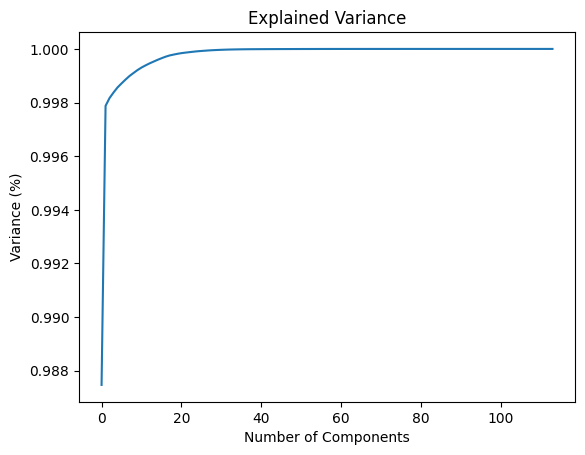

Number of components with eigenvalue > 1: 18
Top contributing variables per principal component:
Principal Component 1:
                         Weight  Absolute Weight
time_baro              0.500006         0.500006
time_accel             0.499989         0.499989
time_linaccel          0.499988         0.499988
time_mergedpost        0.499988         0.499988
accel_inclination_min  0.002916         0.002916

Principal Component 2:
                          Weight  Absolute Weight
accel_inclination_max  -0.572044         0.572044
accel_inclination_mean -0.566392         0.566392
accel_inclination_min  -0.560551         0.560551
accel_y_max            -0.072358         0.072358
accel_y_mean           -0.072081         0.072081

Principal Component 3:
                                 Weight  Absolute Weight
baro_x                        -0.748722         0.748722
accel_zscore_inclination_min   0.216690         0.216690
accel_zscore_y_min             0.210203         0.210203
accel_zsco

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
dataset = pd.read_csv('Imputed_Dataset.csv')

# Exclude non-numeric or identifier columns
cols_to_exclude = ['source_name', 'Unnamed: 0', 'index']
data_for_pca = dataset.drop(columns=cols_to_exclude)

# Fit the PCA
pca = PCA()
principal_components = pca.fit_transform(data_for_pca)
explained_variance = pca.explained_variance_ratio_

# Plot the explained variance
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)')
plt.title('Explained Variance')
plt.show()

# Calculate the number of components with eigenvalue > 1
eigenvalues = pca.explained_variance_
n_components_kaiser = sum(eigenvalues > 1)
print(f"Number of components with eigenvalue > 1: {n_components_kaiser}")

# Print the most influential variables for each principal component
components = pca.components_
num_components = pca.n_components_
feature_names = data_for_pca.columns

print("Top contributing variables per principal component:")
for i, comp in enumerate(components):
    component_df = pd.DataFrame(comp, index=feature_names, columns=['Weight'])
    component_df['Absolute Weight'] = component_df['Weight'].abs()
    sorted_component = component_df.sort_values('Absolute Weight', ascending=False)
    top_features = sorted_component.head(5)  # change count if more or fewer top features are desired
    print(f"Principal Component {i+1}:")
    print(top_features)
    print()




## Analysis of Results

Principal Component 1: Time-related features (time_baro, time_accel, etc.) are dominating, which could be indicative of trends or patterns over time being significant in the dataset.

Principal Component 2 and beyond: Inclination and barometric data (accel_inclination_max, baro_x, etc.) have strong contributions, suggesting these features are critical in explaining the variance in your dataset.

Gyroscope and Accelerometer Data: These features frequently appear in higher principal components, indicating their importance in capturing motion-related aspects or other dynamics in your data.

Principal Component 1 with Top 5 Variables: 
time_baro
time_accel 
time_linaccel 
time_mergedpost  
accel_inclination_min  


Principal Component 2 with Top 5 Variables: 
accel_inclination_max
accel_inclination_mean
accel_inclination_min
accel_y_max
accel_y_mean  

## How many components are needed to reach a certain threshold percentage of explained variance?

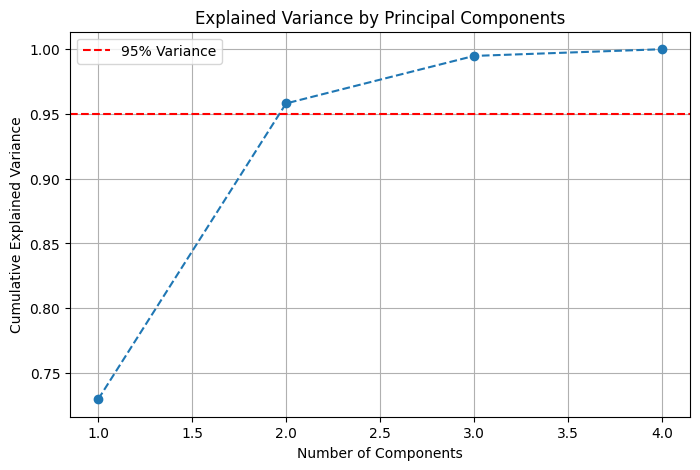

Number of components needed to explain at least 95% of the variance: 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load sample data
# Replace this with your dataset loading code
data = load_iris()
X = data.data

# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Compute explained variance ratio and cumulative sum
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plotting the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance') #Change threshold here
plt.legend()
plt.grid(True)
plt.show()

# Change percentange of variance to test different results
# Check how many components are needed to reach 95% variance
n_components_needed = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components needed to explain at least 95% of the variance: {n_components_needed}")


## Components vs. Explained Variance 

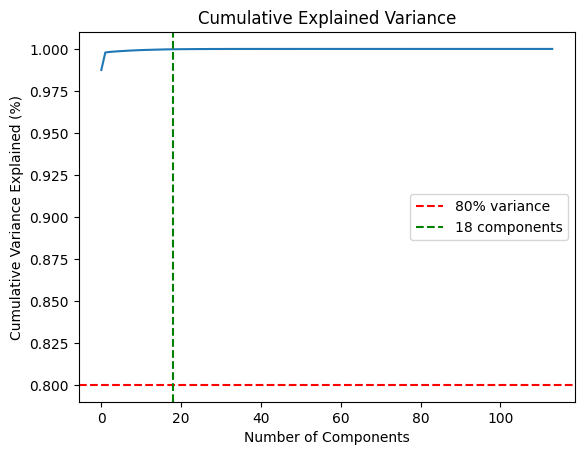

Cumulative explained variance with 18 components: 99.98%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Load the dataset
dataset = pd.read_csv('Imputed_Dataset.csv')

# Exclude non-numeric or identifier columns
cols_to_exclude = ['source_name', 'Unnamed: 0', 'index']
data_for_pca = dataset.drop(columns=cols_to_exclude)

# Fit the PCA
pca = PCA()
principal_components = pca.fit_transform(data_for_pca)
explained_variance = pca.explained_variance_ratio_

# Calculate cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance)


#Change numbers of components & percentange of variance to test different results
# Plot the cumulative explained variance
plt.plot(cumulative_explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axvline(x=18, color='g', linestyle='--', label='18 components') #change number of components if needed
plt.legend()
plt.show()

# Print the cumulative explained variance for the first 18 components
explained_variance_18 = cumulative_explained_variance[17]  # Index 17 is the 18th component
print(f"Cumulative explained variance with 18 components: {explained_variance_18 * 100:.2f}%")

## Save PCA Results to CSV File 

In [ ]:
# Fit PCA with a specific number of components
n_components = 2
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(data_for_pca)

# Save the reduced dataset
pd.DataFrame(reduced_data).to_csv('Reduced_Dataset.csv')

test = r"Reduced_Dataset.csv"
df_test = pd.read_csv(test)
df_test.head()

,Unnamed: 0,0,1
0,0,-295.837894,-14.661686
1,1,-295.645698,-20.220637
2,2,-295.573262,-15.122011
3,3,-295.502219,-10.819788
4,4,-295.390019,-14.028960


In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
dataset = pd.read_csv('Imputed_Dataset.csv')

# Preserve the 'source_name' and 'index' columns before dropping them
columns_to_preserve = dataset[['source_name', 'index']]

# Exclude non-numeric or identifier columns
cols_to_exclude = ['source_name', 'Unnamed: 0', 'index']
data_for_pca = dataset.drop(columns=cols_to_exclude)

# Fit the PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(data_for_pca)
explained_variance = pca.explained_variance_ratio_

# Reconstruct the dataset from the first two principal components
reconstructed_data = pca.inverse_transform(principal_components)

# Create a DataFrame for the reconstructed data
reconstructed_df = pd.DataFrame(reconstructed_data, columns=data_for_pca.columns)

# Add the preserved columns back to the reconstructed DataFrame
reconstructed_df = pd.concat([columns_to_preserve, reconstructed_df], axis=1)

# Save the reconstructed dataset
reconstructed_df.to_csv('Reconstructed_Dataset.csv', index=False)

# Load and display the first few rows of the reconstructed dataset to verify
test = 'Reconstructed_Dataset.csv'
df_test = pd.read_csv(test)
print(df_test.head())


  source_name  index  time_accel  accel_x_max  accel_y_max  accel_z_max  \
0         FB1    0.0    0.157366     0.175159     7.105101     6.828866   
1         FB1    1.0    0.233578     0.203725     7.507411     6.478729   
2         FB1    2.0    0.288033     0.177493     7.138513     6.799800   
3         FB1    3.0    0.338942     0.155357     6.827241     7.070718   
4         FB1    4.0    0.383562     0.171848     7.059495     6.868584   

   accel_inclination_max  accel_zscore_x_max  accel_zscore_y_max  \
0              46.899979            0.289696            0.326562   
1              50.080468            0.301978            0.463080   
2              47.164024            0.290609            0.337990   
3              44.703154            0.281011            0.232444   
4              46.539248            0.288101            0.311257   

   accel_zscore_z_max  ...  gyro_zscore_z_sd  gyro_x_mean  gyro_y_mean  \
0            0.047975  ...          0.209690     0.000189     0.00

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5ea8f536-739f-4c50-806e-84490cb7d5e0' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

# Random Forest - Part 1

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy import fftpack
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import optuna

# Load the dataset
full_data = pd.read_parquet("Emir_Datasets/full_dataset.parquet.gzip")

# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in
                                                                                                        full_data.columns
                                                                                                        if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]


# Optuna objective function for hyperparameter tuning
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 50),
    }

    rf = RandomForestClassifier(**param, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy


# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)

# Train the final model with the best hyperparameters
best_params = study.best_params
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

# Feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()


# Random Forest - Part 2

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy import fftpack
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
import optuna

# Load the dataset
full_data = pd.read_parquet("Emir_Datasets/full_dataset.parquet.gzip")

# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in
                                                                                                        full_data.columns
                                                                                                        if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]


# Optuna objective function for hyperparameter tuning
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 50),
    }

    rf = RandomForestClassifier(**param, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy


# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)

# Train the final model with the best hyperparameters
best_params = study.best_params
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

# Feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest')
plt.gca().invert_yaxis()
plt.show()


# XGBoost

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 34.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 11.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy import fftpack
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import optuna

In [22]:
# Load the dataset
full_data = pd.read_parquet("/content/drive/MyDrive/ml4qs/full_dataset_pre.parquet.gzip")
full_data = full_data[full_data["SM_platform"] != "Red"]

In [23]:
# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]


In [24]:
# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in
                                                                                                        full_data.columns
                                                                                                        if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]


In [25]:
# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]

In [26]:
# Encode the target variable
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [27]:
# Optuna objective function for hyperparameter tuning
def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': len(label_encoder.classes_),
        'eval_metric': 'mlogloss',
        'booster': 'gbtree',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True)
    }

    dtrain = xgb.DMatrix(X_train, label=y_train_encoded)
    dtest = xgb.DMatrix(X_test, label=y_test_encoded)
    cv_results = xgb.cv(param, dtrain, num_boost_round=1000, nfold=5,
                        early_stopping_rounds=10, metrics='mlogloss', seed=42)

    return cv_results['test-mlogloss-mean'].min()


In [28]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)


[I 2024-06-21 11:35:27,598] A new study created in memory with name: no-name-15e8504b-e321-4243-9add-e4876b97c5b1
[I 2024-06-21 11:39:46,314] Trial 0 finished with value: 0.0016664418757539319 and parameters: {'max_depth': 5, 'eta': 0.087032154691288, 'subsample': 0.5002718172610633, 'colsample_bytree': 0.61500281089396, 'lambda': 4.389528739224633e-06, 'alpha': 4.759524820314444e-05}. Best is trial 0 with value: 0.0016664418757539319.
[I 2024-06-21 11:42:51,476] Trial 1 finished with value: 0.001562910738717882 and parameters: {'max_depth': 6, 'eta': 0.13662472138681803, 'subsample': 0.9206899770442027, 'colsample_bytree': 0.5099627855130587, 'lambda': 1.0214104152600185e-08, 'alpha': 0.021299298737343837}. Best is trial 1 with value: 0.001562910738717882.
[I 2024-06-21 11:45:48,797] Trial 2 finished with value: 0.001746476249539542 and parameters: {'max_depth': 4, 'eta': 0.16116523073454994, 'subsample': 0.5277845511384589, 'colsample_bytree': 0.8836178634162027, 'lambda': 3.41303792

Best hyperparameters:  {'max_depth': 4, 'eta': 0.11322774318302968, 'subsample': 0.9661880393103377, 'colsample_bytree': 0.6378373887316273, 'lambda': 9.065132793615444e-05, 'alpha': 1.164583827491238e-06}


Performance with Default Hyperparameters:
Accuracy: 0.7460083187977995
Classification Report:
              precision    recall  f1-score   support

          FB       0.90      1.00      0.95      5996
       Insta       1.00      1.00      1.00      5951
      Reddit       0.11      0.02      0.04      5955
      TikTok       0.46      0.83      0.59      5955
           X       1.00      0.88      0.94      5955

    accuracy                           0.75     29812
   macro avg       0.69      0.75      0.70     29812
weighted avg       0.69      0.75      0.70     29812

Confusion Matrix:
[[5983   13    0    0    0]
 [   3 5948    0    0    0]
 [   0    1  126 5828    0]
 [   0    0 1019 4935    1]
 [ 633    7    0   67 5248]]
   Feature  Importance
58    pc_3      2182.0
57    pc_2      2041.0
60    pc_5       944.0
59    pc_4       775.0
55   index       708.0


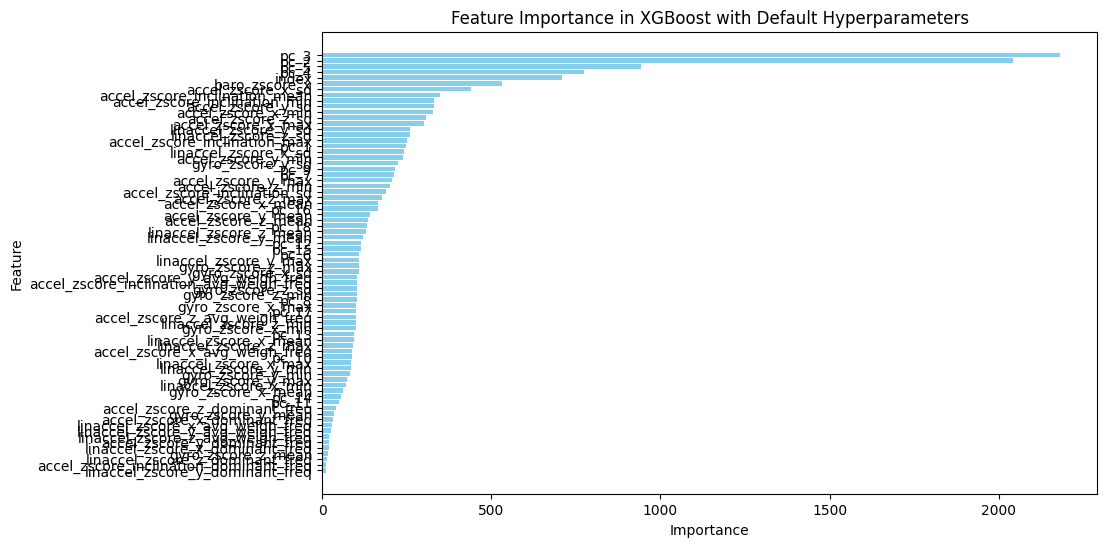

In [33]:
# Train the final model with the default hyperparameters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Load the dataset
#full_data = pd.read_parquet("Emir_Datasets/full_dataset.parquet.gzip")
full_data = pd.read_parquet("/content/drive/MyDrive/ml4qs/full_dataset_pre.parquet.gzip")
full_data = full_data[full_data["SM_platform"] != "Red"]

# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in full_data.columns if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train the model with default hyperparameters
default_params = {
    'objective': 'multi:softprob',
    'num_class': len(label_encoder.classes_),
    'eval_metric': 'mlogloss',
    'learning_rate': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'subsample': 1,
    'colsample_bytree': 1,
    'n_estimators': 100
}

dtrain = xgb.DMatrix(X_train, label=y_train_encoded)
dtest = xgb.DMatrix(X_test, label=y_test_encoded)

default_model = xgb.train(default_params, dtrain, num_boost_round=100)

# Make predictions
y_pred_prob = default_model.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Decode the predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# Evaluate the model
print("Performance with Default Hyperparameters:")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels)}")
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

# Feature importance
importances = default_model.get_score(importance_type='weight')
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBoost with Default Hyperparameters')
plt.gca().invert_yaxis()
plt.show()


In [29]:
# Train the final model with the best hyperparameters
best_params = study.best_params
best_params.update({'objective': 'multi:softprob', 'num_class': len(label_encoder.classes_), 'eval_metric': 'mlogloss'})

dtrain = xgb.DMatrix(X_train, label=y_train_encoded)
dtest = xgb.DMatrix(X_test, label=y_test_encoded)

final_model = xgb.train(best_params, dtrain, num_boost_round=1000,
                        evals=[(dtest, "Test")], early_stopping_rounds=10)


[0]	Test-mlogloss:1.50147
[1]	Test-mlogloss:1.41635
[2]	Test-mlogloss:1.35583
[3]	Test-mlogloss:1.30284
[4]	Test-mlogloss:1.24348
[5]	Test-mlogloss:1.19936
[6]	Test-mlogloss:1.14862
[7]	Test-mlogloss:1.11679
[8]	Test-mlogloss:1.07783
[9]	Test-mlogloss:1.04107
[10]	Test-mlogloss:1.00752
[11]	Test-mlogloss:0.99177
[12]	Test-mlogloss:0.97789
[13]	Test-mlogloss:0.96037
[14]	Test-mlogloss:0.94489
[15]	Test-mlogloss:0.93387
[16]	Test-mlogloss:0.91354
[17]	Test-mlogloss:0.89492
[18]	Test-mlogloss:0.87804
[19]	Test-mlogloss:0.86387
[20]	Test-mlogloss:0.85150
[21]	Test-mlogloss:0.84168
[22]	Test-mlogloss:0.83638
[23]	Test-mlogloss:0.82519
[24]	Test-mlogloss:0.81430
[25]	Test-mlogloss:0.80762
[26]	Test-mlogloss:0.80237
[27]	Test-mlogloss:0.79095
[28]	Test-mlogloss:0.78929
[29]	Test-mlogloss:0.78170
[30]	Test-mlogloss:0.77701
[31]	Test-mlogloss:0.76901
[32]	Test-mlogloss:0.76427
[33]	Test-mlogloss:0.75739
[34]	Test-mlogloss:0.75764
[35]	Test-mlogloss:0.75264
[36]	Test-mlogloss:0.74543
[37]	Test-m

In [30]:
# Make predictions
y_pred_prob = final_model.predict(dtest)
y_pred = y_pred_prob.argmax(axis=1)

# Decode the predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels)}")
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))


Accuracy: 0.740037568764256
Classification Report:
              precision    recall  f1-score   support

          FB       0.83      0.99      0.91      5996
       Insta       0.99      1.00      0.99      5951
      Reddit       0.40      0.13      0.20      5955
      TikTok       0.47      0.80      0.59      5955
           X       1.00      0.78      0.87      5955

    accuracy                           0.74     29812
   macro avg       0.74      0.74      0.71     29812
weighted avg       0.74      0.74      0.71     29812

Confusion Matrix:
[[5960   33    0    0    3]
 [  29 5922    0    0    0]
 [   1    0  791 5158    5]
 [   1    0 1180 4772    2]
 [1154    4    0  180 4617]]


In [31]:
# Feature importance
importances = final_model.get_score(importance_type='weight')
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': list(importances.keys()),
    'Importance': list(importances.values())
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())


                          Feature  Importance
55                           pc_2       964.0
56                           pc_3       835.0
58                           pc_5       329.0
15  accel_zscore_inclination_mean       247.0
57                           pc_4       231.0


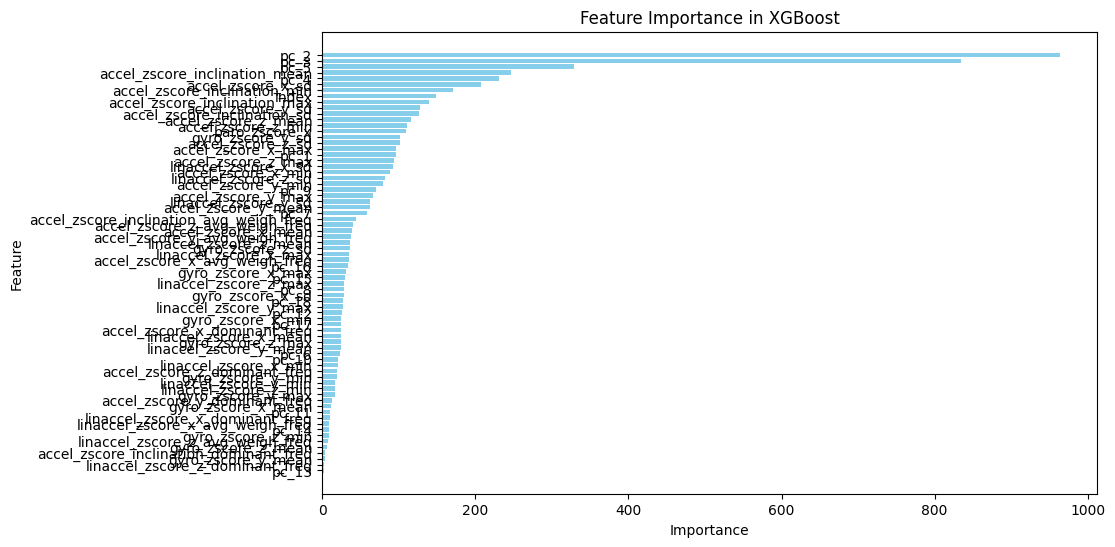

In [32]:
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBoost')
plt.gca().invert_yaxis()
plt.show()


GBM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

# Load the dataset
full_data = pd.read_parquet("/content/drive/MyDrive/ml4qs/full_dataset.parquet.gzip")

# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in full_data.columns if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Train the model with default hyperparameters
default_gbm = GradientBoostingClassifier(random_state=42)
default_gbm.fit(X_train, y_train_encoded)

# Make predictions
y_pred = default_gbm.predict(X_test)

# Decode the predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# Evaluate the model
print("Performance with Default Hyperparameters:")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels)}")
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

# Feature importance
importances = default_gbm.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Gradient Boosting Machines with Default Hyperparameters')
plt.gca().invert_yaxis()
plt.show()


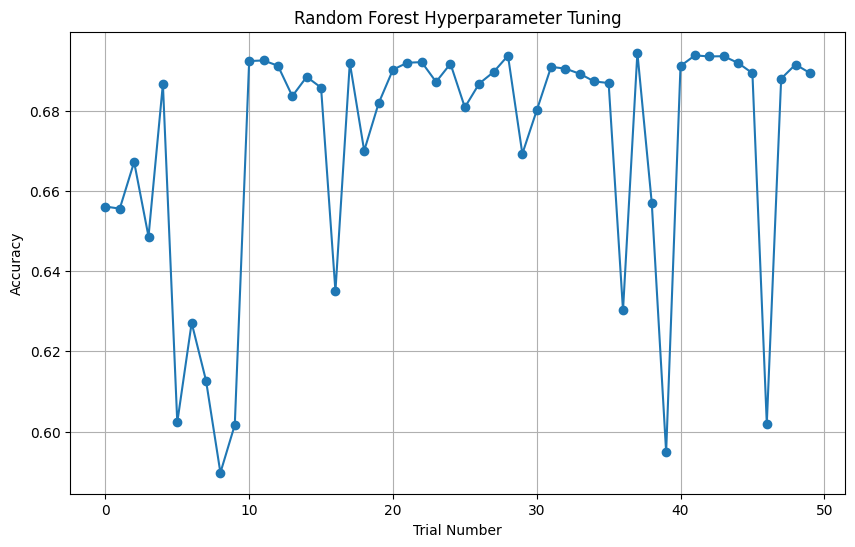

In [ ]:
import matplotlib.pyplot as plt

# Simulate the trials data based on the given output (for demonstration purposes)
trials_data = [
    (0, 0.6560796264713283), (1, 0.6555484105460341), (2, 0.6671792434366874), (3, 0.6485866860513881),
    (4, 0.6866385215422037), (5, 0.6022870243520564), (6, 0.6270864204434256), (7, 0.6126876729946599),
    (8, 0.5897335532753656), (9, 0.6016439734951212), (10, 0.6923421030558895), (11, 0.6924818967204406),
    (12, 0.6911678362736601), (13, 0.6835910196549893), (14, 0.6883999217155479), (15, 0.6857158833561663),
    (16, 0.6349707831241088), (17, 0.6919227220622362), (18, 0.6699751167277099), (19, 0.6817737020158247),
    (20, 0.6901892806218022), (21, 0.6919227220622362), (22, 0.6920625157267872), (23, 0.6871417787345877),
    (24, 0.6916710934660442), (25, 0.6807951463639668), (26, 0.6867223977409344), (27, 0.6896021472306875),
    (28, 0.6936841222355803), (29, 0.6692202309391339), (30, 0.6800402605753907), (31, 0.6908882489445578),
    (32, 0.6904409092179943), (33, 0.689154807504124), (34, 0.6872536136662286), (35, 0.6868621914054855),
    (36, 0.6301898397964604), (37, 0.6944110492912461), (38, 0.6569743059244555), (39, 0.5948500013979366),
    (40, 0.6911119188078396), (41, 0.6937400397014007), (42, 0.6934884111052088), (43, 0.6935443285710292),
    (44, 0.6918668045964157), (45, 0.6893225599015853), (46, 0.6019515195571337), (47, 0.6879525819889842),
    (48, 0.6914753823356725), (49, 0.6893505186344955)
]

# Extract trial numbers and values
trial_numbers, values = zip(*trials_data)

# Plotting the optimization history
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers, values, marker='o')
plt.title('Random Forest Hyperparameter Tuning')
plt.xlabel('Trial Number')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


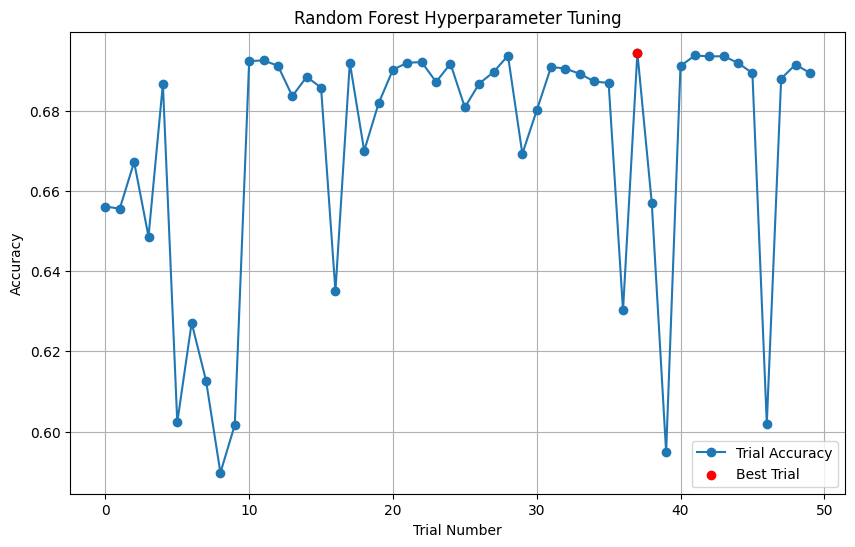

In [ ]:
import matplotlib.pyplot as plt

# Simulate the trials data based on the given output for Random Forest
trials_data_rf = [
    (0, 0.6560796264713283), (1, 0.6555484105460341), (2, 0.6671792434366874), (3, 0.6485866860513881),
    (4, 0.6866385215422037), (5, 0.6022870243520564), (6, 0.6270864204434256), (7, 0.6126876729946599),
    (8, 0.5897335532753656), (9, 0.6016439734951212), (10, 0.6923421030558895), (11, 0.6924818967204406),
    (12, 0.6911678362736601), (13, 0.6835910196549893), (14, 0.6883999217155479), (15, 0.6857158833561663),
    (16, 0.6349707831241088), (17, 0.6919227220622362), (18, 0.6699751167277099), (19, 0.6817737020158247),
    (20, 0.6901892806218022), (21, 0.6919227220622362), (22, 0.6920625157267872), (23, 0.6871417787345877),
    (24, 0.6916710934660442), (25, 0.6807951463639668), (26, 0.6867223977409344), (27, 0.6896021472306875),
    (28, 0.6936841222355803), (29, 0.6692202309391339), (30, 0.6800402605753907), (31, 0.6908882489445578),
    (32, 0.6904409092179943), (33, 0.689154807504124), (34, 0.6872536136662286), (35, 0.6868621914054855),
    (36, 0.6301898397964604), (37, 0.6944110492912461), (38, 0.6569743059244555), (39, 0.5948500013979366),
    (40, 0.6911119188078396), (41, 0.6937400397014007), (42, 0.6934884111052088), (43, 0.6935443285710292),
    (44, 0.6918668045964157), (45, 0.6893225599015853), (46, 0.6019515195571337), (47, 0.6879525819889842),
    (48, 0.6914753823356725), (49, 0.6893505186344955)
]

# Extract trial numbers and values
trial_numbers_rf, values_rf = zip(*trials_data_rf)

# Find the best trial (highest accuracy)
best_trial_index_rf = values_rf.index(max(values_rf))
best_trial_value_rf = max(values_rf)

# Plotting the optimization history
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers_rf, values_rf, marker='o', label='Trial Accuracy')
plt.scatter(best_trial_index_rf, best_trial_value_rf, color='red', zorder=5, label='Best Trial')
plt.title('Random Forest Hyperparameter Tuning')
plt.xlabel('Trial Number')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()


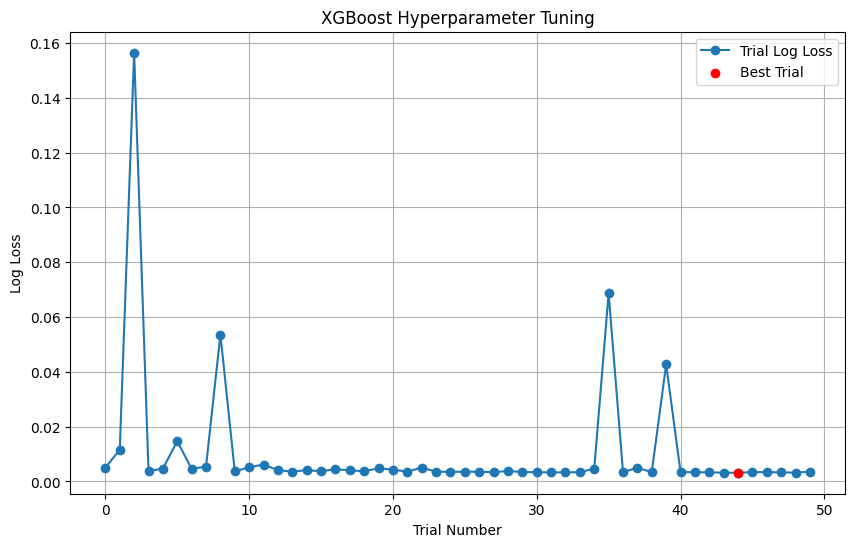

In [ ]:
import matplotlib.pyplot as plt

# Simulate the trials data based on the given output for XGBoost (for demonstration purposes)
trials_data_xgb = [
    (0, 0.0050507832099634655), (1, 0.011585200590160428), (2, 0.15644531325104244), (3, 0.003801919301716884),
    (4, 0.0047220243361594865), (5, 0.014690032957569729), (6, 0.004616372519922318), (7, 0.005459787117075532),
    (8, 0.053586640743222315), (9, 0.0037004394095707764), (10, 0.005189007477426284), (11, 0.00619142379170575),
    (12, 0.0041150516632049395), (13, 0.0036173648053466484), (14, 0.004126629766605454), (15, 0.0037517628041553223),
    (16, 0.004486737033458532), (17, 0.004061232303439599), (18, 0.0037677412236700415), (19, 0.004789572399822016),
    (20, 0.004326339690263422), (21, 0.003585874413694868), (22, 0.005072312796384233), (23, 0.003551176115709416),
    (24, 0.003532676920499476), (25, 0.0035362411784850903), (26, 0.0035798057031829157), (27, 0.0033651657271493384),
    (28, 0.0038371311058486082), (29, 0.0034396839219997476), (30, 0.0034032078819221526), (31, 0.0033205976425699896),
    (32, 0.0033274351161551078), (33, 0.0033976139440563464), (34, 0.004675037278208102), (35, 0.06866774596974642),
    (36, 0.0034320811720943136), (37, 0.005004088247650725), (38, 0.003412299407434988), (39, 0.0427274344401095),
    (40, 0.003474933694977672), (41, 0.003351839269638306), (42, 0.0033521070594251918), (43, 0.0032026697028255066),
    (44, 0.003196855269895142), (45, 0.00342131414691655), (46, 0.003408812744511336), (47, 0.003338250749145516),
    (48, 0.0032124352613627145), (49, 0.0036040479655562382)
]

# Extract trial numbers and values
trial_numbers_xgb, values_xgb = zip(*trials_data_xgb)

# Find the best trial
best_trial_index = values_xgb.index(min(values_xgb))
best_trial_value = min(values_xgb)

# Plotting the optimization history
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers_xgb, values_xgb, marker='o', label='Trial Log Loss')
plt.scatter(best_trial_index, best_trial_value, color='red', zorder=5, label='Best Trial')
plt.title('XGBoost Hyperparameter Tuning')
plt.xlabel('Trial Number')
plt.ylabel('Log Loss')
plt.grid(True)
plt.legend()
plt.show()


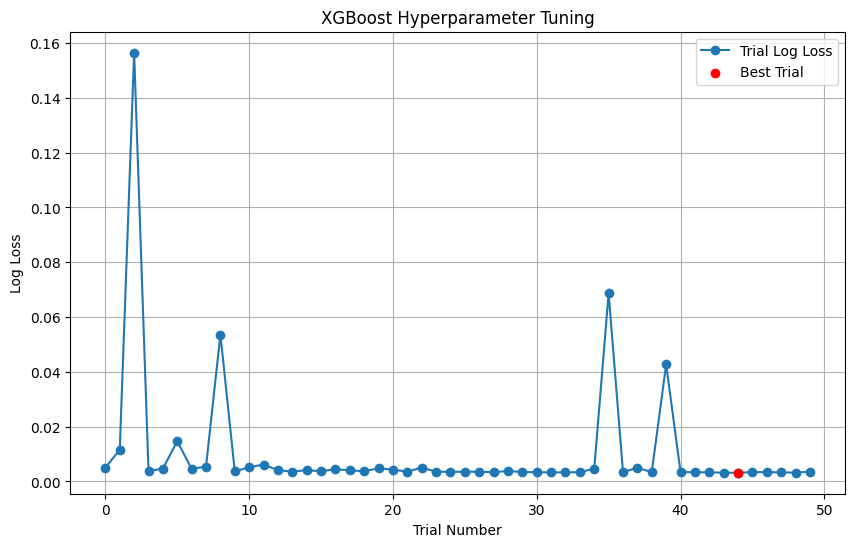

In [ ]:
import matplotlib.pyplot as plt

# Simulate the trials data based on the given output for XGBoost
trials_data_xgb = [
    (0, 0.0050507832099634655), (1, 0.011585200590160428), (2, 0.15644531325104244), (3, 0.003801919301716884),
    (4, 0.0047220243361594865), (5, 0.014690032957569729), (6, 0.004616372519922318), (7, 0.005459787117075532),
    (8, 0.053586640743222315), (9, 0.0037004394095707764), (10, 0.005189007477426284), (11, 0.00619142379170575),
    (12, 0.0041150516632049395), (13, 0.0036173648053466484), (14, 0.004126629766605454), (15, 0.0037517628041553223),
    (16, 0.004486737033458532), (17, 0.004061232303439599), (18, 0.0037677412236700415), (19, 0.004789572399822016),
    (20, 0.004326339690263422), (21, 0.003585874413694868), (22, 0.005072312796384233), (23, 0.003551176115709416),
    (24, 0.003532676920499476), (25, 0.0035362411784850903), (26, 0.0035798057031829157), (27, 0.0033651657271493384),
    (28, 0.0038371311058486082), (29, 0.0034396839219997476), (30, 0.0034032078819221526), (31, 0.0033205976425699896),
    (32, 0.0033274351161551078), (33, 0.0033976139440563464), (34, 0.004675037278208102), (35, 0.06866774596974642),
    (36, 0.0034320811720943136), (37, 0.005004088247650725), (38, 0.003412299407434988), (39, 0.0427274344401095),
    (40, 0.003474933694977672), (41, 0.003351839269638306), (42, 0.0033521070594251918), (43, 0.0032026697028255066),
    (44, 0.003196855269895142), (45, 0.00342131414691655), (46, 0.003408812744511336), (47, 0.003338250749145516),
    (48, 0.0032124352613627145), (49, 0.0036040479655562382)
]

# Extract trial numbers and values
trial_numbers_xgb, values_xgb = zip(*trials_data_xgb)

# Find the best trial
best_trial_index = values_xgb.index(min(values_xgb))
best_trial_value = min(values_xgb)

# Plotting the optimization history
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers_xgb, values_xgb, marker='o', label='Trial Log Loss')
plt.scatter(best_trial_index, best_trial_value, color='red', zorder=5, label='Best Trial')
plt.title('XGBoost Hyperparameter Tuning')
plt.xlabel('Trial Number')
plt.ylabel('Log Loss')
plt.grid(True)
plt.legend()
plt.show()


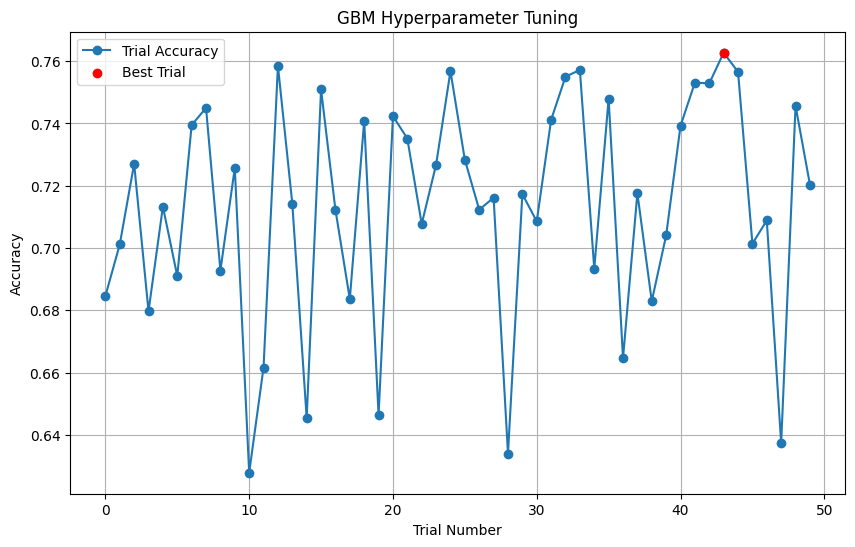

In [ ]:
import matplotlib.pyplot as plt

# Simulate the trials data based on the given output for GBM
trials_data_gbm = [
    (0, 0.6845975340397573), (1, 0.7011491039226102), (2, 0.7270668493303883), (3, 0.6797047557804681),
    (4, 0.7133111527385579), (5, 0.6910000838761987), (6, 0.7394805267425281), (7, 0.7449883971258423),
    (8, 0.6927894427824531), (9, 0.7257248301506976), (10, 0.6278692649649118), (11, 0.661643414320463),
    (12, 0.7584924651214807), (13, 0.7142897083904157), (14, 0.6453714317667123), (15, 0.7509156485028099),
    (16, 0.7123046383537898), (17, 0.6836189783878994), (18, 0.7408225459222189), (19, 0.6463779461514804),
    (20, 0.7423882349651914), (21, 0.7351469231414433), (22, 0.707719406156513), (23, 0.7267593032683759),
    (24, 0.756786982413957), (25, 0.7283529510442587), (26, 0.7123046383537898), (27, 0.7161629434954008),
    (28, 0.6340201862051612), (29, 0.7173372102776302), (30, 0.7085581681438197), (31, 0.7411580507171415),
    (32, 0.7550255822406129), (33, 0.7571784046747001), (34, 0.6933486174406576), (35, 0.747952022814326),
    (36, 0.664634998741857), (37, 0.7176167976067325), (38, 0.6829200100651438), (39, 0.7040568121452736),
    (40, 0.7392568568792462), (41, 0.7531243884027176), (42, 0.7528727598065256), (43, 0.7627142337909246),
    (44, 0.7565633125506752), (45, 0.7014007325188022), (46, 0.7088657142058322), (47, 0.6373193166885677),
    (48, 0.7456873654485978), (49, 0.7203847121648447)
]

# Extract trial numbers and values
trial_numbers_gbm, values_gbm = zip(*trials_data_gbm)

# Find the best trial (highest accuracy)
best_trial_index_gbm = values_gbm.index(max(values_gbm))
best_trial_value_gbm = max(values_gbm)

# Plotting the optimization history
plt.figure(figsize=(10, 6))
plt.plot(trial_numbers_gbm, values_gbm, marker='o', label='Trial Accuracy')
plt.scatter(best_trial_index_gbm, best_trial_value_gbm, color='red', zorder=5, label='Best Trial')
plt.title('GBM Hyperparameter Tuning')
plt.xlabel('Trial Number')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()


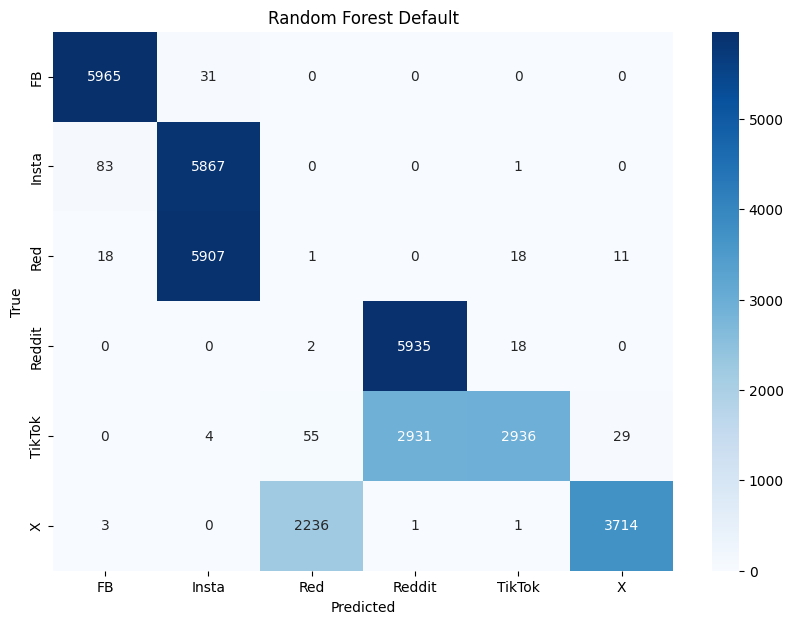

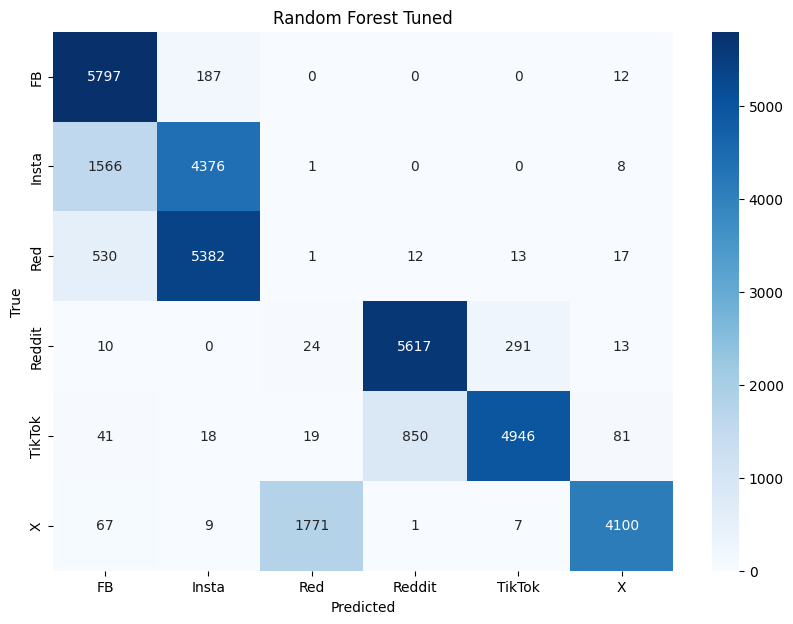

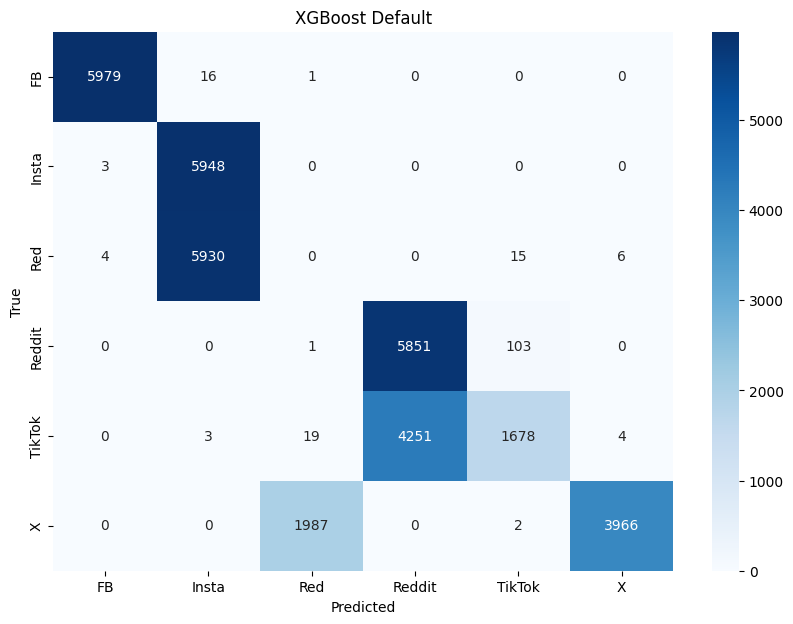

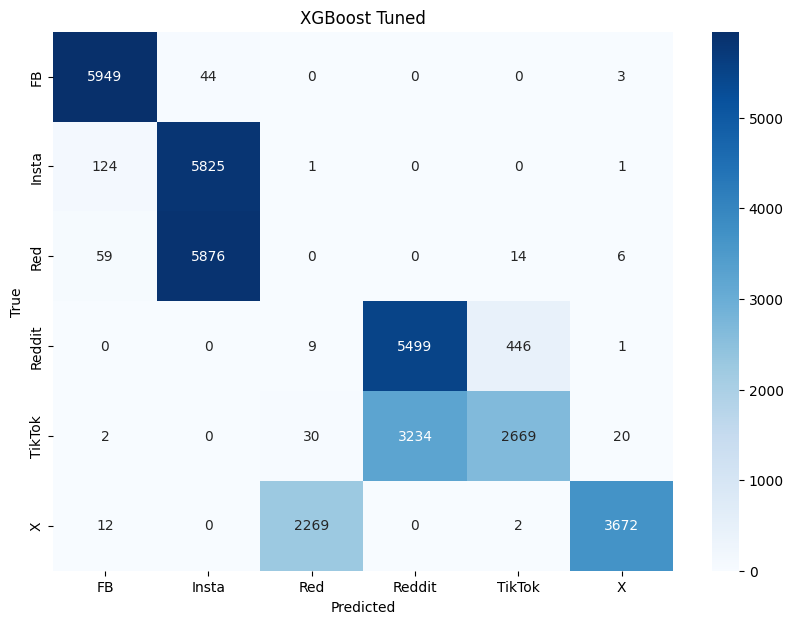

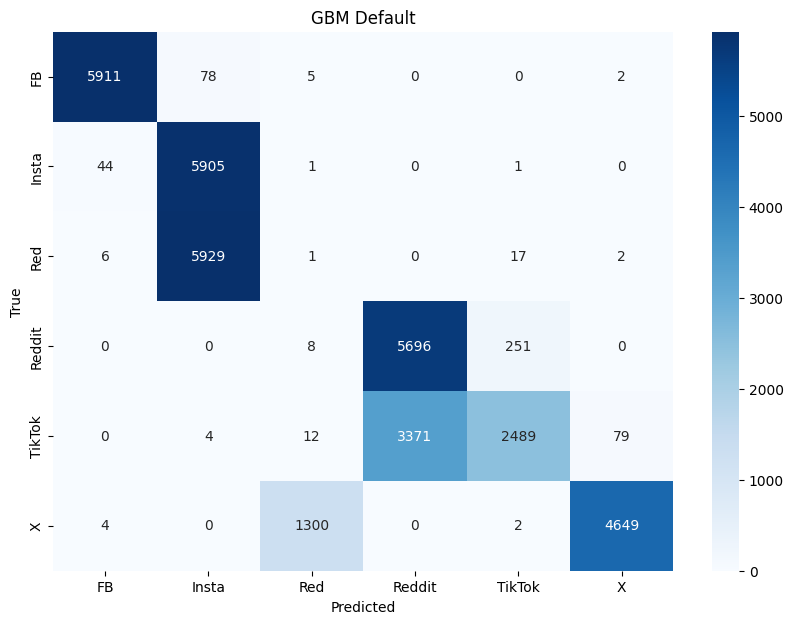

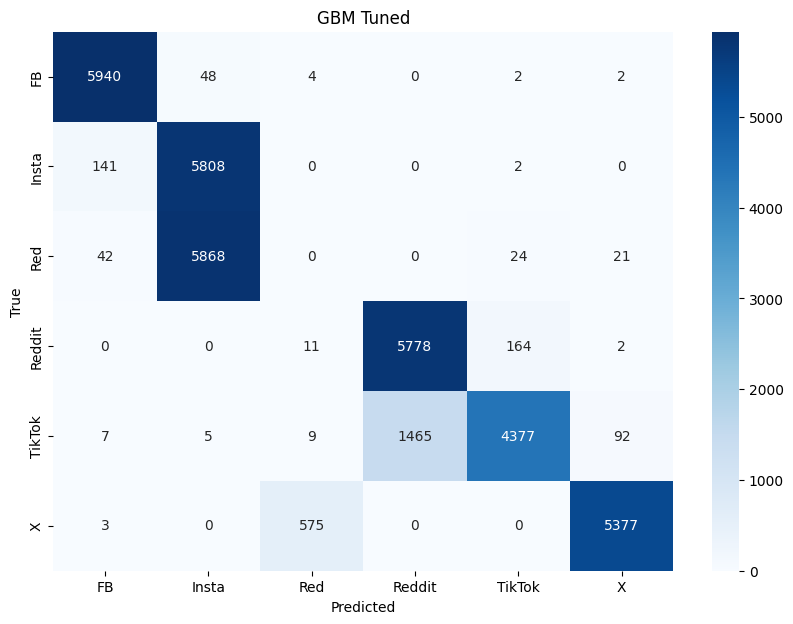

           Model Hyperparameters  Accuracy
0  Random Forest         Default  0.682696
1  Random Forest           Tuned  0.694411
2        XGBoost         Default  0.654849
3        XGBoost           Tuned  0.660218
4            GBM         Default  0.689211
5            GBM           Tuned  0.762714

\begin{table}[ht]
\centering
\begin{tabular}{lll}
\hline
Model & Hyperparameters & Accuracy \\
\hline
Random Forest & Default & 0.6827 \\
Random Forest & Tuned & 0.6944 \\
XGBoost & Default & 0.6548 \\
XGBoost & Tuned & 0.6602 \\
GBM & Default & 0.6892 \\
GBM & Tuned & 0.7627 \\
\hline
\end{tabular}
\caption{Comparison of Model Performance Before and After Tuning}
\end{table}



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Function to plot confusion matrix
def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Data for Random Forest
rf_labels = ["FB", "Insta", "Red", "Reddit", "TikTok", "X"]
rf_cm_default = np.array([[5965, 31, 0, 0, 0, 0],
                          [83, 5867, 0, 0, 1, 0],
                          [18, 5907, 1, 0, 18, 11],
                          [0, 0, 2, 5935, 18, 0],
                          [0, 4, 55, 2931, 2936, 29],
                          [3, 0, 2236, 1, 1, 3714]])

rf_cm_tuned = np.array([[5797, 187, 0, 0, 0, 12],
                        [1566, 4376, 1, 0, 0, 8],
                        [530, 5382, 1, 12, 13, 17],
                        [10, 0, 24, 5617, 291, 13],
                        [41, 18, 19, 850, 4946, 81],
                        [67, 9, 1771, 1, 7, 4100]])

# Data for XGBoost
xgb_labels = ["FB", "Insta", "Red", "Reddit", "TikTok", "X"]
xgb_cm_default = np.array([[5979, 16, 1, 0, 0, 0],
                           [3, 5948, 0, 0, 0, 0],
                           [4, 5930, 0, 0, 15, 6],
                           [0, 0, 1, 5851, 103, 0],
                           [0, 3, 19, 4251, 1678, 4],
                           [0, 0, 1987, 0, 2, 3966]])

xgb_cm_tuned = np.array([[5949, 44, 0, 0, 0, 3],
                         [124, 5825, 1, 0, 0, 1],
                         [59, 5876, 0, 0, 14, 6],
                         [0, 0, 9, 5499, 446, 1],
                         [2, 0, 30, 3234, 2669, 20],
                         [12, 0, 2269, 0, 2, 3672]])

# Data for GBM
gbm_labels = ["FB", "Insta", "Red", "Reddit", "TikTok", "X"]
gbm_cm_default = np.array([[5911, 78, 5, 0, 0, 2],
                           [44, 5905, 1, 0, 1, 0],
                           [6, 5929, 1, 0, 17, 2],
                           [0, 0, 8, 5696, 251, 0],
                           [0, 4, 12, 3371, 2489, 79],
                           [4, 0, 1300, 0, 2, 4649]])

gbm_cm_tuned = np.array([[5940, 48, 4, 0, 2, 2],
                         [141, 5808, 0, 0, 2, 0],
                         [42, 5868, 0, 0, 24, 21],
                         [0, 0, 11, 5778, 164, 2],
                         [7, 5, 9, 1465, 4377, 92],
                         [3, 0, 575, 0, 0, 5377]])

# Plotting confusion matrices
plot_confusion_matrix(rf_cm_default, rf_labels, 'Random Forest Default')
plot_confusion_matrix(rf_cm_tuned, rf_labels, 'Random Forest Tuned')
plot_confusion_matrix(xgb_cm_default, xgb_labels, 'XGBoost Default')
plot_confusion_matrix(xgb_cm_tuned, xgb_labels, 'XGBoost Tuned')
plot_confusion_matrix(gbm_cm_default, gbm_labels, 'GBM Default')
plot_confusion_matrix(gbm_cm_tuned, gbm_labels, 'GBM Tuned')

# Creating tables for comparison
comparison_data = {
    'Model': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost', 'GBM', 'GBM'],
    'Hyperparameters': ['Default', 'Tuned', 'Default', 'Tuned', 'Default', 'Tuned'],
    'Accuracy': [0.6826963402018621, 0.6944110492912461, 0.6548494422232785, 0.6602175189420415, 0.6892107249699444, 0.7627142337909246]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df)

# LaTeX code for table
comparison_table = """
\\begin{table}[ht]
\\centering
\\begin{tabular}{lll}
\\hline
Model & Hyperparameters & Accuracy \\\\
\\hline
Random Forest & Default & 0.6827 \\\\
Random Forest & Tuned & 0.6944 \\\\
XGBoost & Default & 0.6548 \\\\
XGBoost & Tuned & 0.6602 \\\\
GBM & Default & 0.6892 \\\\
GBM & Tuned & 0.7627 \\\\
\\hline
\\end{tabular}
\\caption{Comparison of Model Performance Before and After Tuning}
\\end{table}
"""

print(comparison_table)


# Gradient Boosting Machine (GBM)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
import optuna

# Load the dataset
full_data = pd.read_parquet("Emir_Datasets/full_dataset.parquet.gzip")

# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in
                                                                                                        full_data.columns
                                                                                                        if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# Optuna objective function for hyperparameter tuning
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    gbm = GradientBoostingClassifier(**param, random_state=42)
    gbm.fit(X_train, y_train_encoded)
    y_pred = gbm.predict(X_test)
    accuracy = accuracy_score(y_test_encoded, y_pred)

    return accuracy


# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters: ", study.best_params)

# Train the final model with the best hyperparameters
best_params = study.best_params
gbm_model = GradientBoostingClassifier(**best_params, random_state=42)
gbm_model.fit(X_train, y_train_encoded)

# Make predictions
y_pred = gbm_model.predict(X_test)

# Decode the predictions back to original labels
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels)}")
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

# Feature importance
importances = gbm_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head())

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Gradient Boosting Machines')
plt.gca().invert_yaxis()
plt.show()


# Long Short-Term Memory (LSTM)

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import os
os.chdir('/content/drive/MyDrive/ml4qs/')

In [3]:
!pip install optuna
!pip install tensorflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 10.0 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import optuna

In [5]:
# Load the dataset
full_data = pd.read_parquet("full_dataset.parquet.gzip")
full_data = full_data[full_data["SM_platform"] != "Red"]

In [6]:
# Split the dataset into training and testing sets
random.seed(51)
testing_categories = [1, 2, 3, 4, 5, 6]
random.shuffle(testing_categories)

testing_set = [f"{platform}{number}" for platform, number in zip(full_data["SM_platform"].unique(), testing_categories)]
testing_df = full_data[full_data["source_name"].isin(testing_set)]
training_df = full_data[~full_data["source_name"].isin(testing_set)]

In [7]:
# Only select standardized columns
columns_to_select = [col for col in full_data.columns if 'zscore' in col] + ["SM_platform", "index"] + [col for col in
                                                                                                        full_data.columns
                                                                                                        if 'pc' in col]
training_df = training_df.loc[:, columns_to_select]
testing_df = testing_df.loc[:, columns_to_select]

In [8]:
# Separate features and target
X_train = training_df.drop(columns=["SM_platform"])
y_train = training_df["SM_platform"]
X_test = testing_df.drop(columns=["SM_platform"])
y_test = testing_df["SM_platform"]

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# # Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# reshape data for LSTM (samples, time_steps, features)
X_train = np.expand_dims(X_train.values, axis=2)
X_test = np.expand_dims(X_test.values, axis=2)

In [9]:
# Create sequences for LSTM
def create_sequences(data, target, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:i + sequence_length])
        labels.append(target[i + sequence_length])
    return np.array(sequences), np.array(labels)


sequence_length = 10  # Example sequence length
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_encoded, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_encoded, sequence_length)

In [10]:
# Define the LSTM model
def create_model(trial):
    model = Sequential()
    model.add(LSTM(units=trial.suggest_int('units_1', 32, 128), return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(trial.suggest_float('dropout_1', 0.2, 0.5)))
    model.add(LSTM(units=trial.suggest_int('units_2', 16, 64)))
    model.add(Dropout(trial.suggest_float('dropout_2', 0.2, 0.5)))
    model.add(Dense(units=trial.suggest_int('dense_units', 32, 128), activation='relu'))
    model.add(Dense(units=len(label_encoder.classes_), activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-2)),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [11]:
def objective(trial):
    model = create_model(trial)
    history = model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded),
                        epochs=10, batch_size=trial.suggest_int('batch_size', 32, 128), verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    accuracy = accuracy_score(y_test_encoded, y_pred)

    return accuracy

default training

In [12]:
# Define the LSTM model with default hyperparameters
def create_default_model():
    model = Sequential()
    model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(units=100, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=25, activation='relu'))
    model.add(Dense(units=len(label_encoder.classes_), activation='softmax'))

    optimizer = Adam(learning_rate=1e-3)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [13]:
# Train the model with default hyperparameters
default_model = create_default_model()
history = default_model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
3727/3727 [==============================] - 27s 6ms/step - loss: 0.0212 - accuracy: 0.9937 - val_loss: 9.9175 - val_accuracy: 0.0012
Epoch 2/50
3727/3727 [==============================] - 21s 6ms/step - loss: 0.0037 - accuracy: 0.9991 - val_loss: 16.5558 - val_accuracy: 0.0012
Epoch 3/50
3727/3727 [==============================] - 21s 6ms/step - loss: 0.0043 - accuracy: 0.9990 - val_loss: 14.5484 - val_accuracy: 0.0012
Epoch 4/50
3727/3727 [==============================] - 21s 6ms/step - loss: 0.0025 - accuracy: 0.9994 - val_loss: 16.6237 - val_accuracy: 0.0012
Epoch 5/50
3727/3727 [==============================] - 21s 6ms/step - loss: 4.2279e-04 - accuracy: 1.0000 - val_loss: 21.5056 - val_accuracy: 0.0012
Epoch 6/50
3727/3727 [==============================] - 21s 6ms/step - loss: 0.0024 - accuracy: 0.9994 - val_loss: 26.5830 - val_accuracy: 0.0012
Epoch 7/50
3727/3727 [==============================] - 21s 6ms/step - loss: 0.0011 - accuracy: 0.9997 - val_loss: 31.417

In [14]:
# Evaluate the model
test_loss, test_accuracy = default_model.evaluate(X_test_seq, y_test_seq)
print(f'Test Accuracy: {test_accuracy:.4f}')

932/932 [==============================] - 2s 3ms/step - loss: 10.0662 - accuracy: 0.6074
Test Accuracy: 0.6074


In [15]:
# Predict and generate confusion matrix
y_pred = default_model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)

932/932 [==============================] - 3s 2ms/step


In [16]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test_seq, y_pred_classes)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[5986    0    0    0    0]
 [   7 5944    0    0    0]
 [   0   14  771 5170    0]
 [   0    0  554 5401    0]
 [4677 1138  126   14    0]]


In [17]:
# Classification Report
class_report = classification_report(y_test_seq, y_pred_classes, target_names=label_encoder.classes_)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

          FB       0.56      1.00      0.72      5986
       Insta       0.84      1.00      0.91      5951
      Reddit       0.53      0.13      0.21      5955
      TikTok       0.51      0.91      0.65      5955
           X       0.00      0.00      0.00      5955

    accuracy                           0.61     29802
   macro avg       0.49      0.61      0.50     29802
weighted avg       0.49      0.61      0.50     29802



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


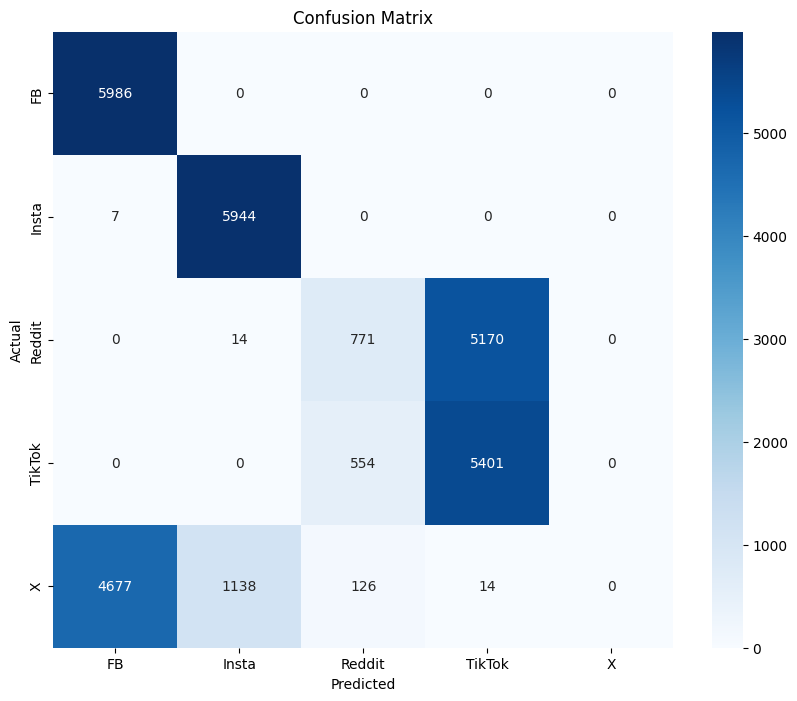

In [18]:
# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

hyperparameter tuning with optuna

In [19]:
# Run Optuna optimization
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2024-06-21 15:32:24,458] A new study created in memory with name: no-name-b6b2ef5d-419c-4350-bb20-a0c82da4a791


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:38:19,281] Trial 0 finished with value: 0.7183013551589964 and parameters: {'units_1': 38, 'dropout_1': 0.37246950302711823, 'units_2': 32, 'dropout_2': 0.35365620972693196, 'dense_units': 82, 'learning_rate': 0.009461159538605522, 'batch_size': 34}. Best is trial 0 with value: 0.7183013551589964.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:41:19,531] Trial 1 finished with value: 0.7496981081443714 and parameters: {'units_1': 107, 'dropout_1': 0.40786604299942136, 'units_2': 17, 'dropout_2': 0.45284166350310295, 'dense_units': 97, 'learning_rate': 0.0017894135140075278, 'batch_size': 74}. Best is trial 1 with value: 0.7496981081443714.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:44:24,067] Trial 2 finished with value: 0.8035019455252919 and parameters: {'units_1': 42, 'dropout_1': 0.47743629120281256, 'units_2': 22, 'dropout_2': 0.21732912585274483, 'dense_units': 48, 'learning_rate': 0.005031226965935945, 'batch_size': 71}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:46:58,481] Trial 3 finished with value: 0.7539916812022005 and parameters: {'units_1': 77, 'dropout_1': 0.4451315375173272, 'units_2': 25, 'dropout_2': 0.22166835301286025, 'dense_units': 101, 'learning_rate': 0.0005432294005924965, 'batch_size': 86}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:50:03,591] Trial 4 finished with value: 0.7621763048436871 and parameters: {'units_1': 108, 'dropout_1': 0.2864139100268909, 'units_2': 23, 'dropout_2': 0.4970628081452521, 'dense_units': 63, 'learning_rate': 0.005060963199066039, 'batch_size': 72}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:54:08,926] Trial 5 finished with value: 0.398866228364417 and parameters: {'units_1': 102, 'dropout_1': 0.37547414210680335, 'units_2': 17, 'dropout_2': 0.296139656003091, 'dense_units': 50, 'learning_rate': 0.0073361838166584505, 'batch_size': 54}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 15:56:14,404] Trial 6 finished with value: 0.7916275325372333 and parameters: {'units_1': 50, 'dropout_1': 0.3112645807009918, 'units_2': 30, 'dropout_2': 0.46809754896189215, 'dense_units': 65, 'learning_rate': 0.0033489995313840315, 'batch_size': 106}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:00:36,879] Trial 7 finished with value: 0.6884140614517644 and parameters: {'units_1': 117, 'dropout_1': 0.34978452723756603, 'units_2': 45, 'dropout_2': 0.3711238365838101, 'dense_units': 69, 'learning_rate': 0.006829344752096514, 'batch_size': 50}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:03:13,658] Trial 8 finished with value: 0.7141419562592245 and parameters: {'units_1': 83, 'dropout_1': 0.24344518939583032, 'units_2': 40, 'dropout_2': 0.34159877725460364, 'dense_units': 81, 'learning_rate': 0.008513328669471831, 'batch_size': 87}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:05:04,557] Trial 9 finished with value: 0.7897490943244331 and parameters: {'units_1': 92, 'dropout_1': 0.2592106015423657, 'units_2': 49, 'dropout_2': 0.25773601965987814, 'dense_units': 50, 'learning_rate': 0.007463152385624908, 'batch_size': 127}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:07:15,462] Trial 10 finished with value: 0.796457802227291 and parameters: {'units_1': 62, 'dropout_1': 0.4912243540191433, 'units_2': 38, 'dropout_2': 0.2017200494507796, 'dense_units': 35, 'learning_rate': 0.00444732523806445, 'batch_size': 102}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:09:14,659] Trial 11 finished with value: 0.7804575338789749 and parameters: {'units_1': 61, 'dropout_1': 0.48647059955206856, 'units_2': 61, 'dropout_2': 0.20120436459411067, 'dense_units': 32, 'learning_rate': 0.004173214965383318, 'batch_size': 113}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:11:27,010] Trial 12 finished with value: 0.7449013819938279 and parameters: {'units_1': 62, 'dropout_1': 0.49797020327741187, 'units_2': 37, 'dropout_2': 0.2614810873014678, 'dense_units': 32, 'learning_rate': 0.005191446790267786, 'batch_size': 100}. Best is trial 2 with value: 0.8035019455252919.


932/932 [==============================] - 4s 3ms/step


[I 2024-06-21 16:14:40,216] Trial 13 finished with value: 0.8207433248356366 and parameters: {'units_1': 36, 'dropout_1': 0.4412334015377209, 'units_2': 49, 'dropout_2': 0.24621854278816105, 'dense_units': 123, 'learning_rate': 0.0030470531114485046, 'batch_size': 67}. Best is trial 13 with value: 0.8207433248356366.


932/932 [==============================] - 5s 4ms/step


[I 2024-06-21 16:18:23,858] Trial 14 finished with value: 0.8273178585804374 and parameters: {'units_1': 32, 'dropout_1': 0.43372040369190307, 'units_2': 55, 'dropout_2': 0.2968639463356105, 'dense_units': 125, 'learning_rate': 0.0026907883594303916, 'batch_size': 57}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:22:07,736] Trial 15 finished with value: 0.7542264859788005 and parameters: {'units_1': 32, 'dropout_1': 0.41674428673993147, 'units_2': 56, 'dropout_2': 0.30514430848348995, 'dense_units': 128, 'learning_rate': 0.0024324656009068577, 'batch_size': 57}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:27:53,697] Trial 16 finished with value: 0.7131356500737958 and parameters: {'units_1': 48, 'dropout_1': 0.20683714400795816, 'units_2': 52, 'dropout_2': 0.4043557778921036, 'dense_units': 128, 'learning_rate': 0.00032943760356963364, 'batch_size': 36}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:31:20,214] Trial 17 finished with value: 0.7412786797262847 and parameters: {'units_1': 32, 'dropout_1': 0.4406629319117379, 'units_2': 62, 'dropout_2': 0.2714983230850093, 'dense_units': 117, 'learning_rate': 0.0018842435319554665, 'batch_size': 62}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:36:10,249] Trial 18 finished with value: 0.7969944988595197 and parameters: {'units_1': 53, 'dropout_1': 0.4524472122378377, 'units_2': 46, 'dropout_2': 0.31923653780217104, 'dense_units': 111, 'learning_rate': 0.0030637463482836406, 'batch_size': 44}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:39:28,245] Trial 19 finished with value: 0.802596269958406 and parameters: {'units_1': 73, 'dropout_1': 0.407356159313201, 'units_2': 53, 'dropout_2': 0.24318004160602638, 'dense_units': 95, 'learning_rate': 0.006203707519148315, 'batch_size': 66}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:42:10,825] Trial 20 finished with value: 0.7507379578693144 and parameters: {'units_1': 43, 'dropout_1': 0.3419409588016132, 'units_2': 57, 'dropout_2': 0.2819237589634604, 'dense_units': 115, 'learning_rate': 0.0010252055839912845, 'batch_size': 81}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:45:29,022] Trial 21 finished with value: 0.7739165436736885 and parameters: {'units_1': 40, 'dropout_1': 0.4642147735463539, 'units_2': 46, 'dropout_2': 0.24400169097379587, 'dense_units': 108, 'learning_rate': 0.003600326318530028, 'batch_size': 65}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:50:04,730] Trial 22 finished with value: 0.7564068160472293 and parameters: {'units_1': 55, 'dropout_1': 0.4264484243951883, 'units_2': 56, 'dropout_2': 0.2298609348437814, 'dense_units': 121, 'learning_rate': 0.006095025368145369, 'batch_size': 46}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:52:59,932] Trial 23 finished with value: 0.784516302160204 and parameters: {'units_1': 41, 'dropout_1': 0.47142338595383254, 'units_2': 41, 'dropout_2': 0.32372657634161034, 'dense_units': 92, 'learning_rate': 0.0026809206449150613, 'batch_size': 74}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:55:22,416] Trial 24 finished with value: 0.7721387360794311 and parameters: {'units_1': 32, 'dropout_1': 0.3909757426747477, 'units_2': 50, 'dropout_2': 0.28869577059089113, 'dense_units': 44, 'learning_rate': 0.004191925862080681, 'batch_size': 93}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 16:58:57,495] Trial 25 finished with value: 0.7466791895880853 and parameters: {'units_1': 69, 'dropout_1': 0.46637538009344537, 'units_2': 33, 'dropout_2': 0.22832258250420817, 'dense_units': 107, 'learning_rate': 0.0016758402060889552, 'batch_size': 60}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:02:00,421] Trial 26 finished with value: 0.8005836575875487 and parameters: {'units_1': 45, 'dropout_1': 0.44101720428387126, 'units_2': 23, 'dropout_2': 0.26291069684408364, 'dense_units': 75, 'learning_rate': 0.005515636424600037, 'batch_size': 71}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:07:03,283] Trial 27 finished with value: 0.7621763048436871 and parameters: {'units_1': 128, 'dropout_1': 0.39070422844911284, 'units_2': 64, 'dropout_2': 0.38072288298429424, 'dense_units': 88, 'learning_rate': 0.003734285332024157, 'batch_size': 43}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:09:46,205] Trial 28 finished with value: 0.811518851469207 and parameters: {'units_1': 56, 'dropout_1': 0.32996813653405943, 'units_2': 44, 'dropout_2': 0.2138957150419837, 'dense_units': 122, 'learning_rate': 0.004580389481305516, 'batch_size': 80}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 5s 4ms/step


[I 2024-06-21 17:16:15,014] Trial 29 finished with value: 0.7743526096873742 and parameters: {'units_1': 56, 'dropout_1': 0.33298485050713167, 'units_2': 43, 'dropout_2': 0.3396391366976028, 'dense_units': 125, 'learning_rate': 0.002780274917605292, 'batch_size': 33}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:19:09,221] Trial 30 finished with value: 0.7573795786931437 and parameters: {'units_1': 39, 'dropout_1': 0.3200658334404649, 'units_2': 58, 'dropout_2': 0.24580871111014793, 'dense_units': 119, 'learning_rate': 0.0022247857382034202, 'batch_size': 81}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:22:23,534] Trial 31 finished with value: 0.7873339594794043 and parameters: {'units_1': 36, 'dropout_1': 0.36894562142688503, 'units_2': 49, 'dropout_2': 0.2101409141147455, 'dense_units': 104, 'learning_rate': 0.004461694808822195, 'batch_size': 68}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:25:31,084] Trial 32 finished with value: 0.772239366697974 and parameters: {'units_1': 47, 'dropout_1': 0.37007587784049417, 'units_2': 32, 'dropout_2': 0.22471940662324938, 'dense_units': 121, 'learning_rate': 0.0012275528245478313, 'batch_size': 78}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:29:58,914] Trial 33 finished with value: 0.7728431504092311 and parameters: {'units_1': 38, 'dropout_1': 0.4276432854515862, 'units_2': 53, 'dropout_2': 0.24293975757634584, 'dense_units': 113, 'learning_rate': 0.00587332620751446, 'batch_size': 54}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:32:35,858] Trial 34 finished with value: 0.7815644706829464 and parameters: {'units_1': 44, 'dropout_1': 0.29283274842253537, 'units_2': 36, 'dropout_2': 0.22027375112734313, 'dense_units': 57, 'learning_rate': 0.00483646602517354, 'batch_size': 89}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:35:39,584] Trial 35 finished with value: 0.76251174023883 and parameters: {'units_1': 66, 'dropout_1': 0.3902171023238123, 'units_2': 18, 'dropout_2': 0.27902931375460216, 'dense_units': 98, 'learning_rate': 0.0033463015789247626, 'batch_size': 77}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:38:13,325] Trial 36 finished with value: 0.7590567556688582 and parameters: {'units_1': 50, 'dropout_1': 0.4665053891356338, 'units_2': 29, 'dropout_2': 0.31062815022958057, 'dense_units': 86, 'learning_rate': 0.0038167246602911382, 'batch_size': 94}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:41:33,592] Trial 37 finished with value: 0.7410103314101704 and parameters: {'units_1': 85, 'dropout_1': 0.4783455572004826, 'units_2': 44, 'dropout_2': 0.21700773058708497, 'dense_units': 74, 'learning_rate': 0.009480379349746736, 'batch_size': 70}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:44:22,748] Trial 38 finished with value: 0.8111498725345498 and parameters: {'units_1': 36, 'dropout_1': 0.2985077285403788, 'units_2': 42, 'dropout_2': 0.2936033433152891, 'dense_units': 102, 'learning_rate': 0.004749323308266078, 'batch_size': 83}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:47:04,082] Trial 39 finished with value: 0.75 and parameters: {'units_1': 36, 'dropout_1': 0.2801554985303674, 'units_2': 48, 'dropout_2': 0.3601205530673437, 'dense_units': 102, 'learning_rate': 0.0030514266185542177, 'batch_size': 83}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:50:42,490] Trial 40 finished with value: 0.7621427613041728 and parameters: {'units_1': 54, 'dropout_1': 0.2997285246527468, 'units_2': 42, 'dropout_2': 0.29865364031911495, 'dense_units': 123, 'learning_rate': 0.0066819912973294275, 'batch_size': 60}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:53:40,448] Trial 41 finished with value: 0.78753522071649 and parameters: {'units_1': 36, 'dropout_1': 0.32595325356176313, 'units_2': 35, 'dropout_2': 0.25319837377222315, 'dense_units': 110, 'learning_rate': 0.005423272725077848, 'batch_size': 75}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 17:57:46,164] Trial 42 finished with value: 0.7465114718905139 and parameters: {'units_1': 45, 'dropout_1': 0.35419935436312666, 'units_2': 29, 'dropout_2': 0.2706033805194544, 'dense_units': 125, 'learning_rate': 0.004797587251019926, 'batch_size': 53}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:00:18,603] Trial 43 finished with value: 0.7595263652220582 and parameters: {'units_1': 51, 'dropout_1': 0.2639721887081522, 'units_2': 40, 'dropout_2': 0.42703056205309364, 'dense_units': 116, 'learning_rate': 0.008053981590548362, 'batch_size': 90}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:02:59,324] Trial 44 finished with value: 0.7898832684824902 and parameters: {'units_1': 58, 'dropout_1': 0.3090953682392074, 'units_2': 47, 'dropout_2': 0.20005201850291043, 'dense_units': 60, 'learning_rate': 0.0039819428705727255, 'batch_size': 84}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:06:21,381] Trial 45 finished with value: 0.7564403595867436 and parameters: {'units_1': 32, 'dropout_1': 0.4536441001439428, 'units_2': 51, 'dropout_2': 0.2316263264997606, 'dense_units': 105, 'learning_rate': 0.004580392499900686, 'batch_size': 65}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:08:26,106] Trial 46 finished with value: 0.7760297866630886 and parameters: {'units_1': 98, 'dropout_1': 0.23097463630075027, 'units_2': 54, 'dropout_2': 0.33212246131697903, 'dense_units': 38, 'learning_rate': 0.005109439419978375, 'batch_size': 114}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:11:28,400] Trial 47 finished with value: 0.7836441701328324 and parameters: {'units_1': 42, 'dropout_1': 0.27853964034174333, 'units_2': 19, 'dropout_2': 0.29196328123018084, 'dense_units': 128, 'learning_rate': 0.005621419690797987, 'batch_size': 72}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:13:47,169] Trial 48 finished with value: 0.794948342949148 and parameters: {'units_1': 36, 'dropout_1': 0.49968542168251734, 'units_2': 39, 'dropout_2': 0.26016274639657333, 'dense_units': 117, 'learning_rate': 0.0064747228043761235, 'batch_size': 96}. Best is trial 14 with value: 0.8273178585804374.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:18:06,064] Trial 49 finished with value: 0.7859922178988327 and parameters: {'units_1': 49, 'dropout_1': 0.40440858266475915, 'units_2': 26, 'dropout_2': 0.21435466920223037, 'dense_units': 100, 'learning_rate': 0.007031071799681923, 'batch_size': 50}. Best is trial 14 with value: 0.8273178585804374.


In [20]:
# Best trial
best_trial = study.best_trial
print(f"Best trial: {best_trial.value}")
print(f"Best hyperparameters: {best_trial.params}")

# Plot optimization history
optuna.visualization.plot_optimization_history(study)
plt.show()

Best trial: 0.8273178585804374
Best hyperparameters: {'units_1': 32, 'dropout_1': 0.43372040369190307, 'units_2': 55, 'dropout_2': 0.2968639463356105, 'dense_units': 125, 'learning_rate': 0.0026907883594303916, 'batch_size': 57}


In [21]:
# Train the best model with the optimal hyperparameters
best_model = create_model(optuna.trial.FixedTrial(best_trial.params))
history = best_model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded), epochs=10, batch_size=best_trial.params['batch_size'], verbose=1)


Epoch 1/10
2616/2616 [==============================] - 28s 10ms/step - loss: 0.3837 - accuracy: 0.8490 - val_loss: 0.9319 - val_accuracy: 0.7319
Epoch 2/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.1553 - accuracy: 0.9449 - val_loss: 0.8255 - val_accuracy: 0.7371
Epoch 3/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.1105 - accuracy: 0.9620 - val_loss: 1.0513 - val_accuracy: 0.7231
Epoch 4/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.0750 - accuracy: 0.9745 - val_loss: 1.0170 - val_accuracy: 0.7794
Epoch 5/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.0598 - accuracy: 0.9795 - val_loss: 1.7507 - val_accuracy: 0.7017
Epoch 6/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.0529 - accuracy: 0.9822 - val_loss: 1.3075 - val_accuracy: 0.7771
Epoch 7/10
2616/2616 [==============================] - 24s 9ms/step - loss: 0.0422 - accuracy: 0.9859 - val_loss: 0.8924 - val_a

In [22]:
# Evaluate the best model
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

932/932 [==============================] - 4s 4ms/step


In [23]:
# Performance report
print("Performance with Tuned Hyperparameters:")
print(f"Accuracy: {accuracy_score(y_test_labels, y_pred_labels)}")
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))

Performance with Tuned Hyperparameters:
Accuracy: 0.7437273581108279
Classification Report:
              precision    recall  f1-score   support

          FB       0.85      0.87      0.86      5996
       Insta       0.89      1.00      0.94      5951
      Reddit       0.72      0.26      0.39      5955
      TikTok       0.52      0.75      0.61      5955
           X       0.79      0.84      0.82      5955

    accuracy                           0.74     29812
   macro avg       0.76      0.74      0.72     29812
weighted avg       0.76      0.74      0.72     29812

Confusion Matrix:
[[5207  710    3    5   71]
 [   7 5939    0    5    0]
 [   3    6 1573 4055  318]
 [   0    0  600 4438  917]
 [ 878   48    1   13 5015]]


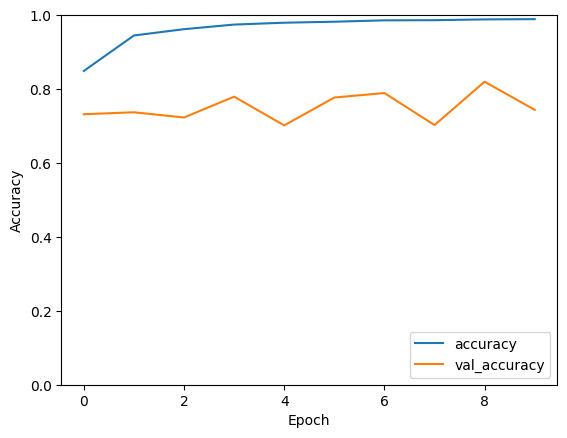

In [24]:
# Plot the feature importances
tf.keras.utils.plot_model(best_model, to_file='best_lstm_model.png', show_shapes=True, show_layer_names=True)

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

update architecture

In [25]:
from tensorflow.keras.layers import Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
# update architecture
def create_model_v1(trial):
    model = Sequential()
    model.add(Bidirectional(LSTM(units=trial.suggest_int('units_1', 32, 128), return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(BatchNormalization())
    model.add(Dropout(trial.suggest_float('dropout_1', 0.2, 0.5)))
    model.add(Bidirectional(LSTM(units=trial.suggest_int('units_2', 16, 64), return_sequences=True)))
    model.add(BatchNormalization())
    model.add(Dropout(trial.suggest_float('dropout_2', 0.2, 0.5)))
    model.add(Bidirectional(LSTM(units=trial.suggest_int('units_3', 16, 64))))
    model.add(BatchNormalization())
    model.add(Dropout(trial.suggest_float('dropout_3', 0.2, 0.5)))
    model.add(Dense(units=trial.suggest_int('dense_units', 32, 128), activation='relu'))
    model.add(Dense(units=len(label_encoder.classes_), activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=trial.suggest_float('learning rate', 1e-4, 1e-2)),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [27]:
# Define the objective function for Optuna
def objective(trial):
    model = create_model(trial)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded),
                        epochs=50, batch_size=trial.suggest_int('batch_size', 32, 128),
                        verbose=0, callbacks=[early_stopping])

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    accuracy = accuracy_score(y_test_encoded, y_pred)

    return accuracy

In [28]:
# Create a study and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2024-06-21 18:22:15,540] A new study created in memory with name: no-name-b2d708b0-dfc2-4582-b2d8-1f2845a68bcb


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:24:25,406] Trial 0 finished with value: 0.8398295988192674 and parameters: {'units_1': 87, 'dropout_1': 0.33692866819002243, 'units_2': 23, 'dropout_2': 0.3916541832003477, 'dense_units': 83, 'learning_rate': 0.005758000047761582, 'batch_size': 99}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:26:26,742] Trial 1 finished with value: 0.8004159398899772 and parameters: {'units_1': 43, 'dropout_1': 0.4795173418279716, 'units_2': 33, 'dropout_2': 0.3013294105184401, 'dense_units': 109, 'learning_rate': 0.004800354722225288, 'batch_size': 124}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:30:04,619] Trial 2 finished with value: 0.7948812558701194 and parameters: {'units_1': 116, 'dropout_1': 0.2169287892871622, 'units_2': 20, 'dropout_2': 0.29118709833055817, 'dense_units': 37, 'learning_rate': 0.003926484261235366, 'batch_size': 64}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:33:13,459] Trial 3 finished with value: 0.6538977592915605 and parameters: {'units_1': 93, 'dropout_1': 0.4885702059529476, 'units_2': 60, 'dropout_2': 0.20776144726792536, 'dense_units': 128, 'learning_rate': 0.00014228000275172167, 'batch_size': 101}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:35:12,656] Trial 4 finished with value: 0.7542264859788005 and parameters: {'units_1': 102, 'dropout_1': 0.47297357296754505, 'units_2': 17, 'dropout_2': 0.3071323939622294, 'dense_units': 50, 'learning_rate': 0.0016049025127158802, 'batch_size': 116}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:38:07,509] Trial 5 finished with value: 0.7072319871192808 and parameters: {'units_1': 44, 'dropout_1': 0.4157642577438277, 'units_2': 60, 'dropout_2': 0.43722091076686387, 'dense_units': 53, 'learning_rate': 0.00500704839268762, 'batch_size': 111}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:44:23,861] Trial 6 finished with value: 0.8016570508520059 and parameters: {'units_1': 74, 'dropout_1': 0.2249490050750475, 'units_2': 48, 'dropout_2': 0.32935959672058057, 'dense_units': 34, 'learning_rate': 0.0038197390333457593, 'batch_size': 57}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:46:37,107] Trial 7 finished with value: 0.792633838722662 and parameters: {'units_1': 44, 'dropout_1': 0.23025262668187013, 'units_2': 52, 'dropout_2': 0.28760653466045394, 'dense_units': 33, 'learning_rate': 0.009417236603593377, 'batch_size': 72}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:49:26,049] Trial 8 finished with value: 0.7697571447739165 and parameters: {'units_1': 42, 'dropout_1': 0.3761871271229969, 'units_2': 64, 'dropout_2': 0.48345068169456473, 'dense_units': 97, 'learning_rate': 0.004587088913423679, 'batch_size': 94}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 18:50:54,692] Trial 9 finished with value: 0.6528243660271031 and parameters: {'units_1': 45, 'dropout_1': 0.37779178206450836, 'units_2': 26, 'dropout_2': 0.45809501205529, 'dense_units': 47, 'learning_rate': 0.0010879479989018112, 'batch_size': 94}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:03:09,159] Trial 10 finished with value: 0.6637595599087616 and parameters: {'units_1': 71, 'dropout_1': 0.30526701618296637, 'units_2': 37, 'dropout_2': 0.40415013433363334, 'dense_units': 72, 'learning_rate': 0.007958822876978489, 'batch_size': 32}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:08:39,692] Trial 11 finished with value: 0.7690191869046021 and parameters: {'units_1': 72, 'dropout_1': 0.28955072342763943, 'units_2': 47, 'dropout_2': 0.3758149455755521, 'dense_units': 76, 'learning_rate': 0.007011904902313727, 'batch_size': 51}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:12:17,736] Trial 12 finished with value: 0.7851871729504898 and parameters: {'units_1': 86, 'dropout_1': 0.28386216369662753, 'units_2': 47, 'dropout_2': 0.34193789494736926, 'dense_units': 90, 'learning_rate': 0.0031994186288703402, 'batch_size': 54}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:14:13,141] Trial 13 finished with value: 0.733664296256541 and parameters: {'units_1': 64, 'dropout_1': 0.2609482276296274, 'units_2': 28, 'dropout_2': 0.3621174518200527, 'dense_units': 66, 'learning_rate': 0.006243441869524255, 'batch_size': 81}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:20:01,984] Trial 14 finished with value: 0.7572118609955723 and parameters: {'units_1': 108, 'dropout_1': 0.32130590299844397, 'units_2': 42, 'dropout_2': 0.22841710534379617, 'dense_units': 93, 'learning_rate': 0.00258307116515083, 'batch_size': 37}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:22:13,668] Trial 15 finished with value: 0.780122098483832 and parameters: {'units_1': 61, 'dropout_1': 0.349214599543651, 'units_2': 52, 'dropout_2': 0.3982371537850617, 'dense_units': 61, 'learning_rate': 0.0060826255598961316, 'batch_size': 82}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:28:08,157] Trial 16 finished with value: 0.6995505165705085 and parameters: {'units_1': 90, 'dropout_1': 0.2003207186038187, 'units_2': 32, 'dropout_2': 0.3351163345570506, 'dense_units': 82, 'learning_rate': 0.008154689327654516, 'batch_size': 54}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:30:37,807] Trial 17 finished with value: 0.7633838722662015 and parameters: {'units_1': 125, 'dropout_1': 0.43475513910768065, 'units_2': 24, 'dropout_2': 0.2554160198975539, 'dense_units': 116, 'learning_rate': 0.0030856800738257527, 'batch_size': 63}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:32:26,178] Trial 18 finished with value: 0.8043069904736347 and parameters: {'units_1': 79, 'dropout_1': 0.24900022718909687, 'units_2': 41, 'dropout_2': 0.417892786056438, 'dense_units': 105, 'learning_rate': 0.006201255621487925, 'batch_size': 90}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:33:50,649] Trial 19 finished with value: 0.7915604454582047 and parameters: {'units_1': 99, 'dropout_1': 0.25030272625335304, 'units_2': 39, 'dropout_2': 0.42582550316069373, 'dense_units': 105, 'learning_rate': 0.009712096874389493, 'batch_size': 103}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:35:40,062] Trial 20 finished with value: 0.8200053669663223 and parameters: {'units_1': 82, 'dropout_1': 0.3353831943177196, 'units_2': 33, 'dropout_2': 0.496372077724698, 'dense_units': 122, 'learning_rate': 0.005981822968187538, 'batch_size': 89}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:38:21,964] Trial 21 finished with value: 0.7938749496846907 and parameters: {'units_1': 81, 'dropout_1': 0.33546294399316384, 'units_2': 32, 'dropout_2': 0.4908461756961333, 'dense_units': 128, 'learning_rate': 0.006055541148380592, 'batch_size': 89}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:40:09,122] Trial 22 finished with value: 0.8019589427076345 and parameters: {'units_1': 61, 'dropout_1': 0.3824521405067302, 'units_2': 22, 'dropout_2': 0.446245860782882, 'dense_units': 118, 'learning_rate': 0.007045623667839505, 'batch_size': 105}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:42:00,496] Trial 23 finished with value: 0.771434321749631 and parameters: {'units_1': 84, 'dropout_1': 0.2741256066175917, 'units_2': 29, 'dropout_2': 0.40380548819747636, 'dense_units': 104, 'learning_rate': 0.006981347125919232, 'batch_size': 88}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:44:15,115] Trial 24 finished with value: 0.7953508654233195 and parameters: {'units_1': 97, 'dropout_1': 0.3201196303532432, 'units_2': 35, 'dropout_2': 0.46845758976973245, 'dense_units': 118, 'learning_rate': 0.00563268302558636, 'batch_size': 73}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:46:52,300] Trial 25 finished with value: 0.7973634777941768 and parameters: {'units_1': 75, 'dropout_1': 0.4100430917636951, 'units_2': 42, 'dropout_2': 0.37273863783060396, 'dense_units': 83, 'learning_rate': 0.00781411664396929, 'batch_size': 96}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:49:00,436] Trial 26 finished with value: 0.7900174426405474 and parameters: {'units_1': 53, 'dropout_1': 0.3601137937199276, 'units_2': 16, 'dropout_2': 0.49678801128067906, 'dense_units': 99, 'learning_rate': 0.005408899735312243, 'batch_size': 113}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:50:11,411] Trial 27 finished with value: 0.6987790151616798 and parameters: {'units_1': 106, 'dropout_1': 0.29983628810397767, 'units_2': 30, 'dropout_2': 0.4232091931225391, 'dense_units': 111, 'learning_rate': 0.008642725986714991, 'batch_size': 127}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:53:25,278] Trial 28 finished with value: 0.7856903260432041 and parameters: {'units_1': 89, 'dropout_1': 0.256626522447796, 'units_2': 38, 'dropout_2': 0.3911714575784502, 'dense_units': 89, 'learning_rate': 0.00669552160589632, 'batch_size': 76}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:55:00,015] Trial 29 finished with value: 0.7655642023346303 and parameters: {'units_1': 68, 'dropout_1': 0.3430742319623524, 'units_2': 35, 'dropout_2': 0.4681593606015975, 'dense_units': 111, 'learning_rate': 0.004304204420514259, 'batch_size': 118}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:56:35,350] Trial 30 finished with value: 0.8011538977592916 and parameters: {'units_1': 79, 'dropout_1': 0.44663733416944096, 'units_2': 20, 'dropout_2': 0.4220023477617422, 'dense_units': 122, 'learning_rate': 0.005553874601468683, 'batch_size': 89}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 19:59:05,600] Trial 31 finished with value: 0.7868978934657185 and parameters: {'units_1': 59, 'dropout_1': 0.38067004017625267, 'units_2': 23, 'dropout_2': 0.4538345263565461, 'dense_units': 119, 'learning_rate': 0.007226690125641911, 'batch_size': 105}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:00:25,070] Trial 32 finished with value: 0.7797195760096606 and parameters: {'units_1': 32, 'dropout_1': 0.39882521939202104, 'units_2': 21, 'dropout_2': 0.4403202028523189, 'dense_units': 109, 'learning_rate': 0.007456792879242059, 'batch_size': 104}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:02:26,760] Trial 33 finished with value: 0.7856232389641755 and parameters: {'units_1': 55, 'dropout_1': 0.35974889509586394, 'units_2': 25, 'dropout_2': 0.47517847809780633, 'dense_units': 123, 'learning_rate': 0.006571928359528621, 'batch_size': 109}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:03:57,904] Trial 34 finished with value: 0.7294713538172548 and parameters: {'units_1': 78, 'dropout_1': 0.31499262036733533, 'units_2': 19, 'dropout_2': 0.4538372881751247, 'dense_units': 101, 'learning_rate': 0.00870455023638144, 'batch_size': 98}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:05:21,555] Trial 35 finished with value: 0.8178585804374078 and parameters: {'units_1': 93, 'dropout_1': 0.47138961479202135, 'units_2': 42, 'dropout_2': 0.4383083576533884, 'dense_units': 114, 'learning_rate': 0.005129786440027268, 'batch_size': 122}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:06:45,755] Trial 36 finished with value: 0.7621763048436871 and parameters: {'units_1': 93, 'dropout_1': 0.46464630620161795, 'units_2': 41, 'dropout_2': 0.4277641751251301, 'dense_units': 128, 'learning_rate': 0.005097009366973577, 'batch_size': 120}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:08:01,973] Trial 37 finished with value: 0.8161814034616933 and parameters: {'units_1': 117, 'dropout_1': 0.23839264664350618, 'units_2': 46, 'dropout_2': 0.3838328625851009, 'dense_units': 111, 'learning_rate': 0.004203995929168056, 'batch_size': 124}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:10:49,222] Trial 38 finished with value: 0.7829732993425467 and parameters: {'units_1': 119, 'dropout_1': 0.43947178478887317, 'units_2': 44, 'dropout_2': 0.3815606425338824, 'dense_units': 114, 'learning_rate': 0.004083593251509083, 'batch_size': 122}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:14:19,260] Trial 39 finished with value: 0.8137662686166645 and parameters: {'units_1': 112, 'dropout_1': 0.47413017061891866, 'units_2': 44, 'dropout_2': 0.314761565578683, 'dense_units': 94, 'learning_rate': 0.004716804935706596, 'batch_size': 127}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:15:42,097] Trial 40 finished with value: 0.7705286461827452 and parameters: {'units_1': 125, 'dropout_1': 0.4957968228469983, 'units_2': 52, 'dropout_2': 0.3671501905259121, 'dense_units': 123, 'learning_rate': 0.0036743780503075245, 'batch_size': 114}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:17:11,003] Trial 41 finished with value: 0.7847846504763183 and parameters: {'units_1': 113, 'dropout_1': 0.4623103953256153, 'units_2': 49, 'dropout_2': 0.2919006559004468, 'dense_units': 95, 'learning_rate': 0.004749829493419069, 'batch_size': 124}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:18:25,842] Trial 42 finished with value: 0.7267543271165974 and parameters: {'units_1': 119, 'dropout_1': 0.47151085917626145, 'units_2': 45, 'dropout_2': 0.31839878008422506, 'dense_units': 88, 'learning_rate': 0.0050740203860355415, 'batch_size': 128}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:20:09,897] Trial 43 finished with value: 0.8087011941500067 and parameters: {'units_1': 106, 'dropout_1': 0.4841779649536535, 'units_2': 50, 'dropout_2': 0.34788743040802295, 'dense_units': 75, 'learning_rate': 0.004620575795580354, 'batch_size': 110}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:22:16,226] Trial 44 finished with value: 0.832013954112438 and parameters: {'units_1': 111, 'dropout_1': 0.45672484265798086, 'units_2': 54, 'dropout_2': 0.2760098373730812, 'dense_units': 108, 'learning_rate': 0.003458395554678175, 'batch_size': 117}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:24:57,676] Trial 45 finished with value: 0.7610693680397156 and parameters: {'units_1': 100, 'dropout_1': 0.4249695922132243, 'units_2': 57, 'dropout_2': 0.26796470361752595, 'dense_units': 110, 'learning_rate': 0.0024799492235353425, 'batch_size': 117}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:27:10,001] Trial 46 finished with value: 0.8091708037032067 and parameters: {'units_1': 94, 'dropout_1': 0.39421503410635317, 'units_2': 60, 'dropout_2': 0.35635171729984766, 'dense_units': 107, 'learning_rate': 0.003610413132799974, 'batch_size': 99}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:29:29,504] Trial 47 finished with value: 0.7813632094458607 and parameters: {'units_1': 128, 'dropout_1': 0.4546933100174056, 'units_2': 56, 'dropout_2': 0.2060510491700174, 'dense_units': 40, 'learning_rate': 0.0022753925097898555, 'batch_size': 109}. Best is trial 0 with value: 0.8398295988192674.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:31:50,099] Trial 48 finished with value: 0.852173621360526 and parameters: {'units_1': 103, 'dropout_1': 0.22533842840317808, 'units_2': 55, 'dropout_2': 0.22651653925108772, 'dense_units': 61, 'learning_rate': 0.0019277191666681854, 'batch_size': 84}. Best is trial 48 with value: 0.852173621360526.


932/932 [==============================] - 4s 4ms/step


[I 2024-06-21 20:33:39,195] Trial 49 finished with value: 0.6499396216288743 and parameters: {'units_1': 85, 'dropout_1': 0.20530487134000736, 'units_2': 55, 'dropout_2': 0.2502141417384582, 'dense_units': 56, 'learning_rate': 0.000723763646597528, 'batch_size': 82}. Best is trial 48 with value: 0.852173621360526.


In [29]:
# Print best hyperparameters
print('Best hyperparameters:', study.best_params)

# Visualize the optimization history
optuna.visualization.plot_optimization_history(study)
plt.show()

# Visualize the hyperparameter importance
optuna.visualization.plot_param_importances(study)
plt.show()

Best hyperparameters: {'units_1': 103, 'dropout_1': 0.22533842840317808, 'units_2': 55, 'dropout_2': 0.22651653925108772, 'dense_units': 61, 'learning_rate': 0.0019277191666681854, 'batch_size': 84}


In [30]:
# Train the best model using the best hyperparameters
best_trial = study.best_trial
best_model = create_model(best_trial)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
best_model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded),
               epochs=50, batch_size=best_trial.params['batch_size'],
               verbose=1, callbacks=[early_stopping])

Epoch 1/50
1775/1775 [==============================] - 21s 10ms/step - loss: 0.3351 - accuracy: 0.8672 - val_loss: 1.1196 - val_accuracy: 0.7494
Epoch 2/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0786 - accuracy: 0.9731 - val_loss: 1.1152 - val_accuracy: 0.7839
Epoch 3/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0499 - accuracy: 0.9827 - val_loss: 1.1111 - val_accuracy: 0.7800
Epoch 4/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0393 - accuracy: 0.9865 - val_loss: 1.5403 - val_accuracy: 0.7703
Epoch 5/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0336 - accuracy: 0.9886 - val_loss: 1.1755 - val_accuracy: 0.7846
Epoch 6/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0282 - accuracy: 0.9904 - val_loss: 0.8721 - val_accuracy: 0.8059
Epoch 7/50
1775/1775 [==============================] - 18s 10ms/step - loss: 0.0261 - accuracy: 0.9913 - val_loss: 0.9653 -

932/932 [==============================] - 4s 4ms/step
Accuracy of the best model: 0.7548973567690863
Classification Report:
              precision    recall  f1-score   support

          FB       0.97      0.98      0.98      5996
       Insta       0.98      0.99      0.98      5951
      Reddit       0.41      0.36      0.38      5955
      TikTok       0.42      0.47      0.44      5955
           X       0.99      0.97      0.98      5955

    accuracy                           0.75     29812
   macro avg       0.75      0.75      0.75     29812
weighted avg       0.75      0.75      0.75     29812



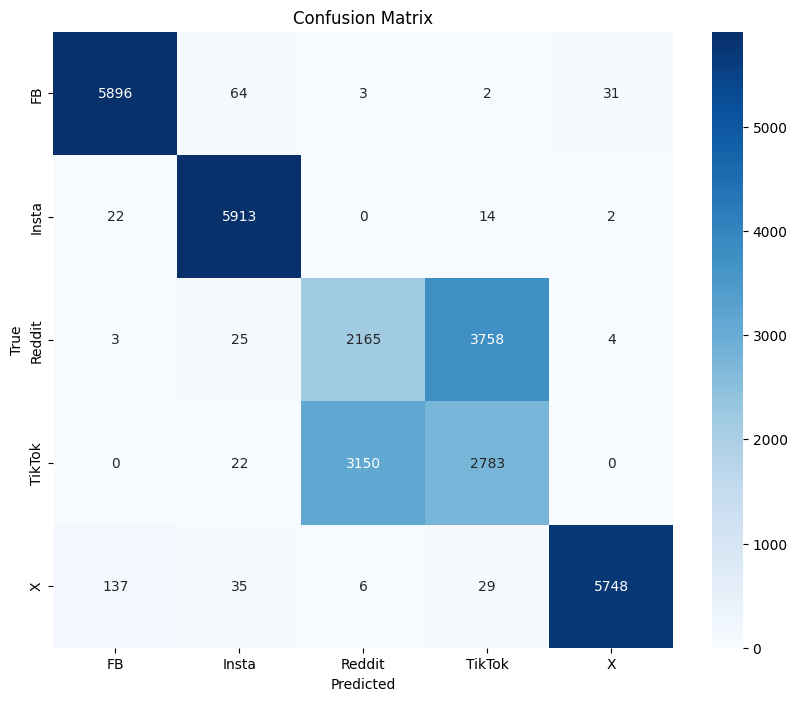

In [31]:
# Evaluate the best model
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy of the best model: {accuracy}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [32]:
from keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when a metric has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.001)

# Early stopping callback with higher patience
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with the best hyperparameters found
best_model.fit(X_train, y_train_encoded, validation_data=(X_test, y_test_encoded),
               epochs=50, batch_size=best_trial.params['batch_size'],
               verbose=1, callbacks=[early_stopping, reduce_lr])


Epoch 1/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0172 - accuracy: 0.9945 - val_loss: 0.9229 - val_accuracy: 0.8200 - lr: 0.0019
Epoch 2/50
1775/1775 [==============================] - 18s 10ms/step - loss: 0.0161 - accuracy: 0.9948 - val_loss: 1.1417 - val_accuracy: 0.7901 - lr: 0.0019
Epoch 3/50
1775/1775 [==============================] - 18s 10ms/step - loss: 0.0125 - accuracy: 0.9961 - val_loss: 1.3462 - val_accuracy: 0.7919 - lr: 0.0019
Epoch 4/50
1775/1775 [==============================] - 18s 10ms/step - loss: 0.0142 - accuracy: 0.9955 - val_loss: 1.5690 - val_accuracy: 0.8029 - lr: 0.0019
Epoch 5/50
1775/1775 [==============================] - 18s 10ms/step - loss: 0.0059 - accuracy: 0.9979 - val_loss: 1.8538 - val_accuracy: 0.8043 - lr: 0.0010
Epoch 6/50
1775/1775 [==============================] - 17s 10ms/step - loss: 0.0065 - accuracy: 0.9983 - val_loss: 1.6458 - val_accuracy: 0.7988 - lr: 0.0010
Epoch 7/50
1775/1775 [========================

932/932 [==============================] - 4s 4ms/step
Accuracy of the best model: 0.819971823426808
Classification Report:
              precision    recall  f1-score   support

          FB       0.99      0.98      0.99      5996
       Insta       0.99      1.00      1.00      5951
      Reddit       0.58      0.49      0.53      5955
      TikTok       0.56      0.64      0.59      5955
           X       0.99      0.99      0.99      5955

    accuracy                           0.82     29812
   macro avg       0.82      0.82      0.82     29812
weighted avg       0.82      0.82      0.82     29812



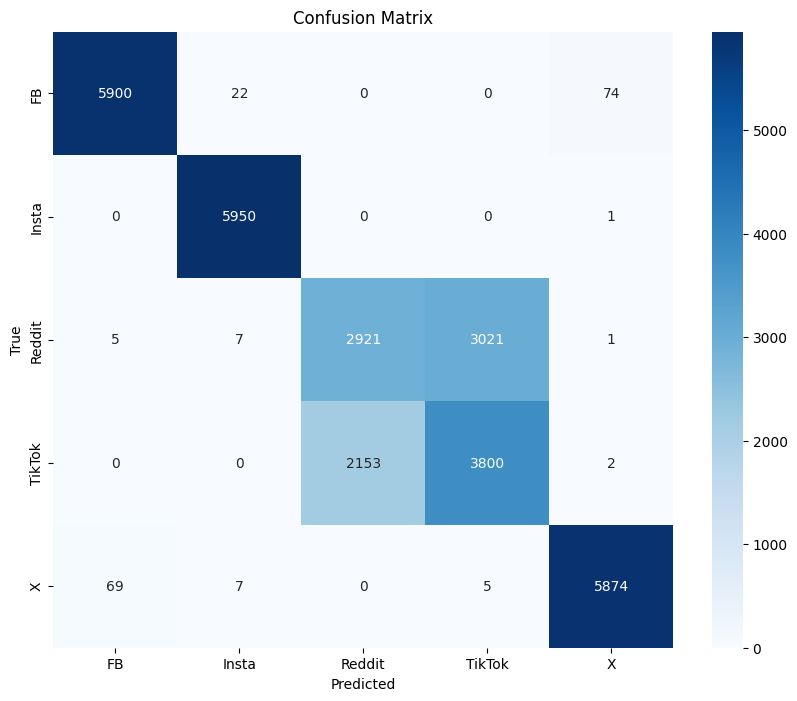

In [33]:
# Evaluate the best model
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy of the best model: {accuracy}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

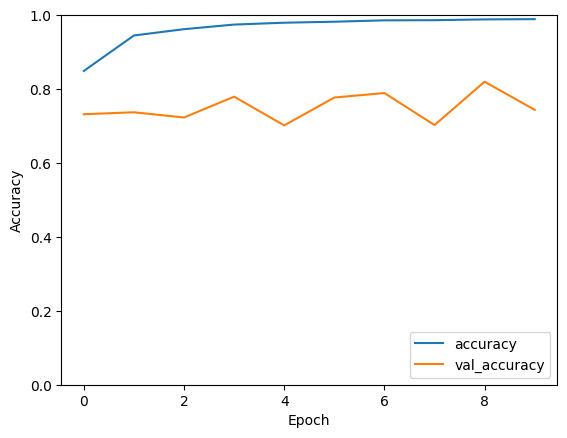

In [34]:
# Plot the feature importances
tf.keras.utils.plot_model(best_model, to_file='best_lstm_model.png', show_shapes=True, show_layer_names=True)

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()